<a href="https://www.kaggle.com/code/tejaswinikantrathi/hybrid-attention-gan-cnn-transformer-final?scriptVersionId=348096857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ================================================================
# CELL 1 — SETUP FOR EXPERIMENT 1–9 IMAGE COMPARISON
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ------------------------------------------------
# DEVICE
# ------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("EXPERIMENT 1–9 — IMAGE COMPARISON SETUP")
print("=" * 70)

print("Device :", device)

if device.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

# ------------------------------------------------
# TEST DATA PATHS
# ------------------------------------------------

test_noisy_dir = (
  "/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206"
)

test_clean_dir = (
    "/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206"
)

print()
print("Test noisy directory :", test_noisy_dir)
print("Test clean directory :", test_clean_dir)

# ------------------------------------------------
# CHECK PATHS
# ------------------------------------------------

print()
print("Noisy directory :", "FOUND ✓"
      if os.path.exists(test_noisy_dir)
      else "MISSING ✗")

print("Clean directory :", "FOUND ✓"
      if os.path.exists(test_clean_dir)
      else "MISSING ✗")

print("=" * 70)
print("CELL 1 SETUP COMPLETED ✓")
print("=" * 70)

EXPERIMENT 1–9 — IMAGE COMPARISON SETUP
Device : cuda
GPU    : Tesla T4

Test noisy directory : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206
Test clean directory : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206

Noisy directory : FOUND ✓
Clean directory : FOUND ✓
CELL 1 SETUP COMPLETED ✓


In [2]:
# Cell 2 — Set Random Seeds
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed configured successfully ✅")
print("Seed:", SEED)

Random seed configured successfully ✅
Seed: 42


In [3]:
# Cell 3 — Configure Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device configured successfully ✅")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device configured successfully ✅
Using device: cuda
GPU: Tesla T4


In [4]:
# Cell 4 — Project Configuration

IMAGE_SIZE = 256

BATCH_SIZE = 8

LEARNING_RATE_G = 2e-4
LEARNING_RATE_D = 2e-4

NUM_EPOCHS = 50

LAMBDA_RECON = 100.0
LAMBDA_STRUCT = 10.0
LAMBDA_ADV = 1.0

NUM_WORKERS = 2

print("Project configuration created successfully ✅")
print("Image size       :", IMAGE_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Generator LR     :", LEARNING_RATE_G)
print("Discriminator LR :", LEARNING_RATE_D)
print("Epochs            :", NUM_EPOCHS)
print("Reconstruction λ  :", LAMBDA_RECON)
print("Structural λ      :", LAMBDA_STRUCT)
print("Adversarial λ     :", LAMBDA_ADV)
print("Workers           :", NUM_WORKERS)

Project configuration created successfully ✅
Image size       : 256
Batch size       : 8
Generator LR     : 0.0002
Discriminator LR : 0.0002
Epochs            : 50
Reconstruction λ  : 100.0
Structural λ      : 10.0
Adversarial λ     : 1.0
Workers           : 2


In [5]:
# Cell 5 — Define Dataset Paths

DATASET_ROOT = "/kaggle/input/datasets/tejaswinikantrathi/nr206-n2201/NR206_Full_Version/NR206"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

print("Dataset paths configured successfully ✅")
print("Dataset root :", DATASET_ROOT)
print("Train path   :", TRAIN_DIR)
print("Validation   :", VAL_DIR)
print("Test path    :", TEST_DIR)

Dataset paths configured successfully ✅
Dataset root : /kaggle/input/datasets/tejaswinikantrathi/nr206-n2201/NR206_Full_Version/NR206
Train path   : /kaggle/input/datasets/tejaswinikantrathi/nr206-n2201/NR206_Full_Version/NR206/train
Validation   : /kaggle/input/datasets/tejaswinikantrathi/nr206-n2201/NR206_Full_Version/NR206/val
Test path    : /kaggle/input/datasets/tejaswinikantrathi/nr206-n2201/NR206_Full_Version/NR206/test


In [6]:
# ============================================================
# FIND THE ACTUAL DATASET PATH
# ============================================================

import os

print("=" * 70)
print("SEARCHING KAGGLE INPUT FOR OCT DATASET")
print("=" * 70)

for root, dirs, files in os.walk("/kaggle/input"):

    # Show directories containing image files
    image_files = [
        f for f in files
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
        )
    ]

    if image_files:
        print("\n📁 IMAGE DIRECTORY FOUND:")
        print(root)
        print("Images:", len(image_files))

SEARCHING KAGGLE INPUT FOR OCT DATASET

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/val_labels
Images: 40

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/test_labels
Images: 40

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/val
Images: 40

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/train_labels
Images: 126

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/test
Images: 40

📁 IMAGE DIRECTORY FOUND:
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/train
Images: 126


In [7]:
# ============================================================
# CORRECT OCT DATASET PATHS
# ============================================================

import os

DATASET_ROOT = (
    "/kaggle/input/datasets/tejaswinikantrathi/"
    "nr206-full-version/NR206_Full_Version/NR206"
)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

TRAIN_LABEL_DIR = os.path.join(DATASET_ROOT, "train_labels")
VAL_LABEL_DIR   = os.path.join(DATASET_ROOT, "val_labels")
TEST_LABEL_DIR  = os.path.join(DATASET_ROOT, "test_labels")

print("=" * 70)
print("CORRECTED OCT DATASET PATHS")
print("=" * 70)

print("Dataset root :", DATASET_ROOT)
print("Train folder :", TRAIN_DIR)
print("Val folder   :", VAL_DIR)
print("Test folder  :", TEST_DIR)

print("\nChecking folders...")

assert os.path.isdir(TRAIN_DIR), "Training folder not found!"
assert os.path.isdir(VAL_DIR), "Validation folder not found!"
assert os.path.isdir(TEST_DIR), "Testing folder not found!"

print("\n✓ Training folder found")
print("✓ Validation folder found")
print("✓ Testing folder found")

print("\nImage counts:")

def count_images(folder):
    extensions = (".png", ".jpg", ".jpeg")
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith(extensions)
    )

print("Training images   :", count_images(TRAIN_DIR))
print("Validation images :", count_images(VAL_DIR))
print("Testing images    :", count_images(TEST_DIR))

print("\n" + "=" * 70)
print("DATASET PATHS READY ✓")
print("=" * 70)

CORRECTED OCT DATASET PATHS
Dataset root : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206
Train folder : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/train
Val folder   : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/val
Test folder  : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/test

Checking folders...

✓ Training folder found
✓ Validation folder found
✓ Testing folder found

Image counts:
Training images   : 126
Validation images : 40
Testing images    : 40

DATASET PATHS READY ✓


In [8]:
# Cell 7 — Count OCT Images

IMAGE_EXTENSIONS = (
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
)

def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ])

train_count = count_images(TRAIN_DIR)
val_count   = count_images(VAL_DIR)
test_count  = count_images(TEST_DIR)

print("OCT image counts:")
print("-----------------")
print("Training   :", train_count)
print("Validation :", val_count)
print("Testing    :", test_count)
print("Total      :", train_count + val_count + test_count)

OCT image counts:
-----------------
Training   : 126
Validation : 40
Testing    : 40
Total      : 206


Sample image loaded successfully ✅
File name : NORMAL1.png
Image size: (750, 500)
Image mode: L


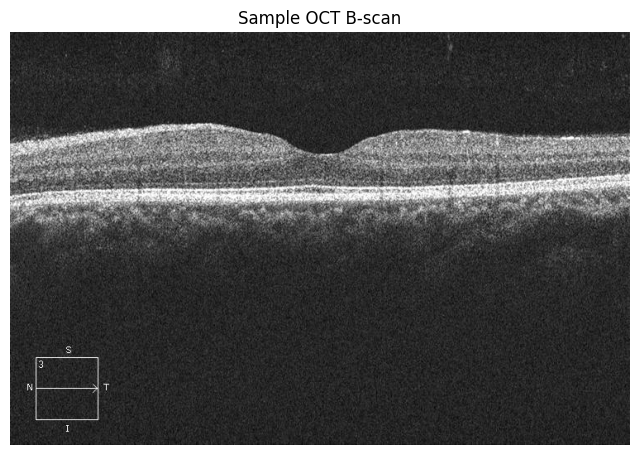

In [9]:
# Cell 8 — Display One OCT Image

train_files = sorted([
    f for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
])

sample_path = os.path.join(TRAIN_DIR, train_files[0])

sample_image = Image.open(sample_path).convert("L")

print("Sample image loaded successfully ✅")
print("File name :", train_files[0])
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

plt.figure(figsize=(8, 6))
plt.imshow(sample_image, cmap="gray")
plt.title("Sample OCT B-scan")
plt.axis("off")
plt.show()

In [10]:
# Cell 9 — Create Project Output Directories

OUTPUT_ROOT = "/kaggle/working/OCT_Hybrid_Attention_GAN"

RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
CHECKPOINT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")
IMAGE_RESULTS_DIR = os.path.join(RESULTS_DIR, "images")
GRAPH_RESULTS_DIR = os.path.join(RESULTS_DIR, "graphs")

for folder in [
    OUTPUT_ROOT,
    RESULTS_DIR,
    CHECKPOINT_DIR,
    IMAGE_RESULTS_DIR,
    GRAPH_RESULTS_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Project directories created successfully ✅")
print("Output root      :", OUTPUT_ROOT)
print("Results          :", RESULTS_DIR)
print("Checkpoints      :", CHECKPOINT_DIR)
print("Result images    :", IMAGE_RESULTS_DIR)
print("Result graphs    :", GRAPH_RESULTS_DIR)

Project directories created successfully ✅
Output root      : /kaggle/working/OCT_Hybrid_Attention_GAN
Results          : /kaggle/working/OCT_Hybrid_Attention_GAN/results
Checkpoints      : /kaggle/working/OCT_Hybrid_Attention_GAN/checkpoints
Result images    : /kaggle/working/OCT_Hybrid_Attention_GAN/results/images
Result graphs    : /kaggle/working/OCT_Hybrid_Attention_GAN/results/graphs


In [11]:
# Cell 10 — OCT Image Preprocessing

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Image size used by the model
IMAGE_SIZE = 256

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

print("=" * 60)
print("OCT PREPROCESSING")
print("=" * 60)

print("Image size : ", IMAGE_SIZE)
print("Channels   : 1")
print("Normalization: [-1, 1]")
print("Preprocessing pipeline created successfully ✓")

OCT PREPROCESSING
Image size :  256
Channels   : 1
Normalization: [-1, 1]
Preprocessing pipeline created successfully ✓


In [12]:
# Cell 11 — OCT Dataset Class

import os
from PIL import Image
from torch.utils.data import Dataset

class OCTDataset(Dataset):
    """
    Dataset class for loading OCT images
    and applying preprocessing.
    """

    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # Get all image files
        self.image_files = [
            os.path.join(image_dir, file)
            for file in os.listdir(image_dir)
            if file.lower().endswith((
                ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"
            ))
        ]

        # Sort for reproducibility
        self.image_files.sort()

        if len(self.image_files) == 0:
            raise RuntimeError(
                f"No OCT images found in: {image_dir}"
            )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):

        # Load image
        image_path = self.image_files[index]
        image = Image.open(image_path).convert("L")

        # Apply preprocessing
        if self.transform is not None:
            image = self.transform(image)

        return image


print("=" * 60)
print("OCT DATASET CLASS")
print("=" * 60)
print("Dataset class created successfully ✓")

OCT DATASET CLASS
Dataset class created successfully ✓


In [13]:
# Find available Kaggle input datasets

import os

print("Available datasets:\n")

for item in os.listdir("/kaggle/input"):
    print("/kaggle/input/" + item)

Available datasets:

/kaggle/input/datasets


In [14]:
# Show the folders/files inside the dataset

DATASET_ROOT = "/kaggle/input/datasets"

for root, dirs, files in os.walk(DATASET_ROOT):
    print(root)
    print("  Folders:", dirs[:10])
    print("  Files :", files[:5])

/kaggle/input/datasets
  Folders: ['tejaswinikantrathi']
  Files : []
/kaggle/input/datasets/tejaswinikantrathi
  Folders: ['nr206-full-version']
  Files : []
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version
  Folders: ['NR206_Full_Version']
  Files : []
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version
  Folders: ['NR206']
  Files : ['README.md']
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206
  Folders: ['val_labels', 'test_labels', 'val', 'train_labels', 'test', 'train']
  Files : ['Retina_class_dict.csv']
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/val_labels
  Folders: []
  Files : ['NORMAL168.png', 'NORMAL135.png', 'NORMAL161.png', 'NORMAL139.png', 'NORMAL206.png']
/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/test_labels
  Folders: []
  Files : ['NORMAL5.png', 'NORMAL46.png', 'NORMAL38.png', 'NORMAL4.png', 'NORMAL16.png

In [15]:
# Cell 12 — Create OCT Train, Validation and Test Datasets

import os

# ============================================================
# DATASET PATH
# ============================================================

DATASET_ROOT = ("/kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206"
    
)

# Dataset folders
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

# ============================================================
# CHECK FOLDERS
# ============================================================

print("=" * 60)
print("OCT DATASET PATH CHECK")
print("=" * 60)

print("Dataset root :", DATASET_ROOT)
print("Train folder :", TRAIN_DIR)
print("Val folder   :", VAL_DIR)
print("Test folder  :", TEST_DIR)

assert os.path.exists(TRAIN_DIR), "Training folder not found!"
assert os.path.exists(VAL_DIR), "Validation folder not found!"
assert os.path.exists(TEST_DIR), "Test folder not found!"

print("\nAll dataset folders found ✓")

# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = OCTDataset(
    image_dir=TRAIN_DIR,
    transform=transform
)

val_dataset = OCTDataset(
    image_dir=VAL_DIR,
    transform=transform
)

test_dataset = OCTDataset(
    image_dir=TEST_DIR,
    transform=transform
)

# ============================================================
# DISPLAY DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("OCT DATASETS CREATED SUCCESSFULLY")
print("=" * 60)

print("Training images   :", len(train_dataset))
print("Validation images :", len(val_dataset))
print("Testing images    :", len(test_dataset))

OCT DATASET PATH CHECK
Dataset root : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206
Train folder : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/train
Val folder   : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/val
Test folder  : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/test

All dataset folders found ✓

OCT DATASETS CREATED SUCCESSFULLY
Training images   : 126
Validation images : 40
Testing images    : 40


SINGLE OCT IMAGE TEST
Image shape : torch.Size([1, 256, 256])
Data type   : torch.float32
Min value   : -0.8196078538894653
Max value   : 0.9764705896377563


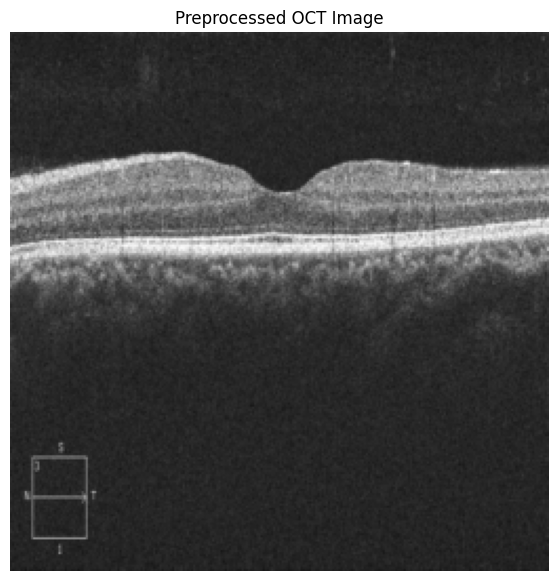

OCT image loaded and visualized successfully ✓


In [16]:
# Cell 13 — Test and Visualize Preprocessed OCT Image

import matplotlib.pyplot as plt

# Get one image from the training dataset
sample_image = train_dataset[0]

# Check tensor information
print("=" * 60)
print("SINGLE OCT IMAGE TEST")
print("=" * 60)

print("Image shape :", sample_image.shape)
print("Data type   :", sample_image.dtype)
print("Min value   :", sample_image.min().item())
print("Max value   :", sample_image.max().item())

# Convert tensor from [-1, 1] to [0, 1] for display
display_image = sample_image.squeeze().detach().cpu().numpy()
display_image = (display_image + 1.0) / 2.0

# Display image
plt.figure(figsize=(7, 7))

plt.imshow(
    display_image,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Preprocessed OCT Image")
plt.axis("off")
plt.show()

print("OCT image loaded and visualized successfully ✓")

In [17]:
# Cell 14 — Create DataLoaders

from torch.utils.data import DataLoader

# Batch size
BATCH_SIZE = 8

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 60)
print("DATALOADERS CREATED")
print("=" * 60)

print("Batch size        :", BATCH_SIZE)
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))

print("\nDataLoaders created successfully ✓")

DATALOADERS CREATED
Batch size        : 8
Training batches  : 16
Validation batches: 5
Testing batches   : 5

DataLoaders created successfully ✓


In [18]:
# Cell 15 — Verify OCT DataLoader Batch

print("=" * 60)
print("DATALOADER BATCH VERIFICATION")
print("=" * 60)

# Get one batch
batch = next(iter(train_loader))

# Display batch information
print("Batch shape :", batch.shape)
print("Data type   :", batch.dtype)
print("Min value   :", batch.min().item())
print("Max value   :", batch.max().item())

# Expected shape: [Batch, Channels, Height, Width]
expected_shape = (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)

print("\nExpected shape :", expected_shape)

# Verify dimensions
assert batch.shape == expected_shape, (
    f"Unexpected batch shape: {batch.shape}"
)

# Check for NaN / Inf
assert torch.isfinite(batch).all(), (
    "Batch contains NaN or Inf values!"
)

print("\n✓ Batch shape is correct")
print("✓ No NaN or Inf values found")
print("✓ DataLoader verification successful")

DATALOADER BATCH VERIFICATION
Batch shape : torch.Size([8, 1, 256, 256])
Data type   : torch.float32
Min value   : -0.8352941274642944
Max value   : 0.9686274528503418

Expected shape : (8, 1, 256, 256)

✓ Batch shape is correct
✓ No NaN or Inf values found
✓ DataLoader verification successful


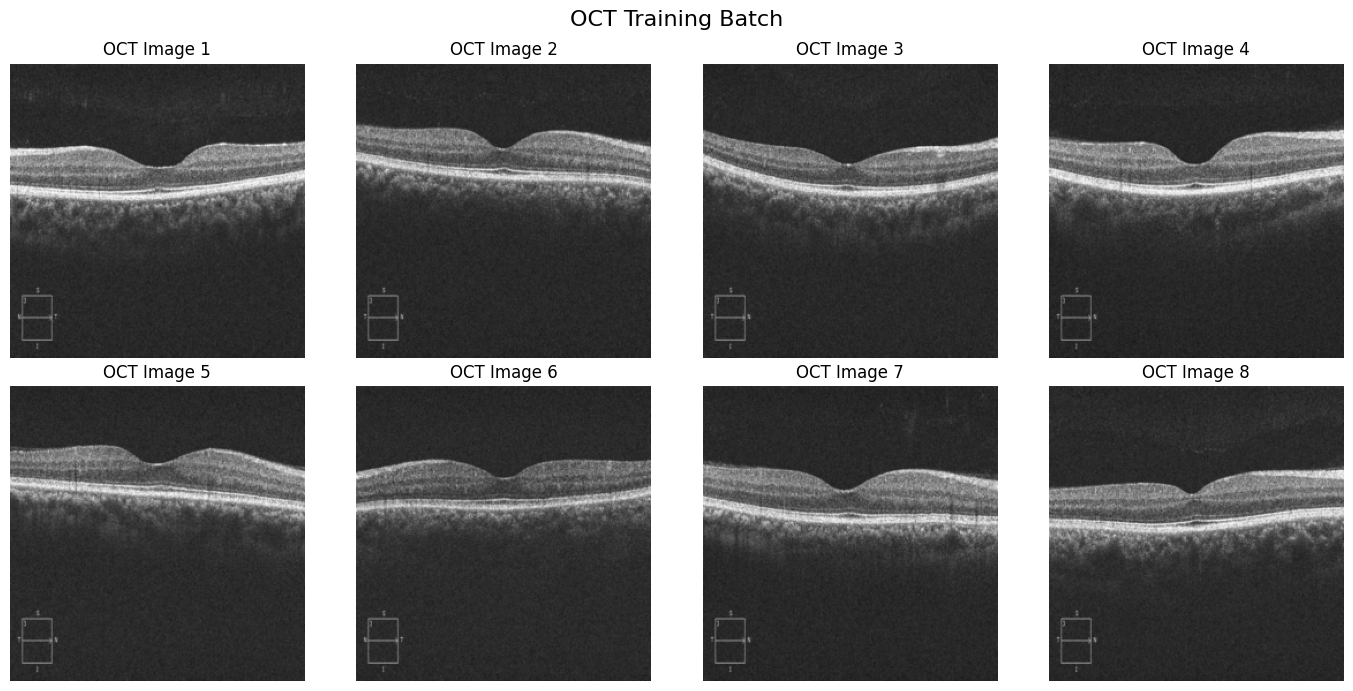

Batch visualization completed successfully ✓


In [19]:
# Cell 16 — Visualize OCT Training Batch

import matplotlib.pyplot as plt

batch = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):

    image = batch[i].squeeze().detach().cpu().numpy()

    # Convert [-1, 1] → [0, 1]
    image = (image + 1.0) / 2.0

    ax.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(f"OCT Image {i + 1}")
    ax.axis("off")

plt.suptitle("OCT Training Batch", fontsize=16)
plt.tight_layout()
plt.show()

print("Batch visualization completed successfully ✓")

In [20]:
# Cell 16.5 — Device Setup

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("=" * 60)
print("DEVICE SETUP")
print("=" * 60)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available — using CPU")

print("\nDevice setup successful ✓")

DEVICE SETUP
Device: cuda
GPU: Tesla T4

Device setup successful ✓


In [21]:
# Cell 16.6 — CUDA Compatibility Check

import torch

print("=" * 60)
print("CUDA COMPATIBILITY CHECK")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA version    :", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("GPU capability  :", torch.cuda.get_device_capability(0))

    print("\nPyTorch CUDA architectures:")
    print(torch.cuda.get_arch_list())

CUDA COMPATIBILITY CHECK
PyTorch version : 2.10.0+cu128
CUDA version    : 12.8
CUDA available  : True
GPU             : Tesla T4
GPU capability  : (7, 5)

PyTorch CUDA architectures:
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [22]:
# CUDA FIX — PyTorch version compatible with Tesla P100

!pip install -q --force-reinstall \
    torch==2.5.1 \
    torchvision==0.20.1 \
    torchaudio==2.5.1 \
    --index-url https://download.pytorch.org/whl/cu124

ERROR: Could not find a version that satisfies the requirement torch==2.5.1 (from versions: none)
ERROR: No matching distribution found for torch==2.5.1


In [23]:
# Check PyTorch after restart

import torch

print("=" * 60)
print("PYTORCH / CUDA CHECK")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA version    :", torch.version.cuda)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("GPU capability  :", torch.cuda.get_device_capability(0))
    print("Supported arch  :", torch.cuda.get_arch_list())

PYTORCH / CUDA CHECK
PyTorch version : 2.10.0+cu128
CUDA version    : 12.8
CUDA available  : True
GPU             : Tesla T4
GPU capability  : (7, 5)
Supported arch  : ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [24]:
# ============================================================
# Cell 17 — CNN Encoder
# ============================================================

import torch
import torch.nn as nn

class CNNEncoder(nn.Module):
    """
    CNN encoder for OCT local feature extraction.

    Input:
        [B, 1, 256, 256]

    Output:
        [B, 128, 64, 64]
    """

    def __init__(
        self,
        in_channels=1,
        base_channels=32
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            # ------------------------------------------------
            # Block 1
            # 256 × 256 → 256 × 256
            # ------------------------------------------------
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=base_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels),
            nn.LeakyReLU(0.2, inplace=True),

            # ------------------------------------------------
            # Block 2
            # 256 × 256 → 128 × 128
            # ------------------------------------------------
            nn.Conv2d(
                in_channels=base_channels,
                out_channels=base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # ------------------------------------------------
            # Block 3
            # 128 × 128 → 64 × 64
            # ------------------------------------------------
            nn.Conv2d(
                in_channels=base_channels * 2,
                out_channels=base_channels * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.encoder(x)


# ------------------------------------------------------------
# Create CNN encoder
# ------------------------------------------------------------

cnn_encoder = CNNEncoder(
    in_channels=1,
    base_channels=32
).to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

cnn_parameters = sum(
    p.numel()
    for p in cnn_encoder.parameters()
)


print("=" * 60)
print("CNN ENCODER")
print("=" * 60)

print("Input shape       : [B, 1, 256, 256]")
print("Output shape      : [B, 128, 64, 64]")
print("Base channels     : 32")
print(f"Parameters        : {cnn_parameters:,}")

print("\nCNN Encoder created successfully ✓")

CNN ENCODER
Input shape       : [B, 1, 256, 256]
Output shape      : [B, 128, 64, 64]
Base channels     : 32
Parameters        : 164,576

CNN Encoder created successfully ✓


In [25]:
# ============================================================
# Cell 19 — Channel Attention
# ============================================================

import torch
import torch.nn as nn


class ChannelAttention(nn.Module):
    """
    Channel Attention module.

    Learns which feature channels are important
    for OCT structure restoration.

    Input:
        [B, 128, 64, 64]

    Output:
        [B, 128, 64, 64]
    """

    def __init__(self, channels=128, reduction=8):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        hidden_channels = max(channels // reduction, 1)

        self.mlp = nn.Sequential(
            nn.Conv2d(
                channels,
                hidden_channels,
                kernel_size=1,
                bias=False
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                hidden_channels,
                channels,
                kernel_size=1,
                bias=False
            )
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Average-pooled channel information
        avg_attention = self.mlp(
            self.avg_pool(x)
        )

        # Max-pooled channel information
        max_attention = self.mlp(
            self.max_pool(x)
        )

        # Combine both
        attention = avg_attention + max_attention

        # Convert to weights [0, 1]
        attention = self.sigmoid(attention)

        # Apply channel weights
        return x * attention


# ------------------------------------------------------------
# Create Channel Attention
# ------------------------------------------------------------

channel_attention = ChannelAttention(
    channels=128,
    reduction=8
).to(device)


# Count parameters
attention_parameters = sum(
    p.numel()
    for p in channel_attention.parameters()
)

print("=" * 60)
print("CHANNEL ATTENTION")
print("=" * 60)

print("Input channels :", 128)
print("Reduction      :", 8)
print(f"Parameters     : {attention_parameters:,}")

print("\nChannel Attention created successfully ✓")

CHANNEL ATTENTION
Input channels : 128
Reduction      : 8
Parameters     : 4,096

Channel Attention created successfully ✓


In [26]:
# ============================================================
# Cell 20 — Spatial Attention
# ============================================================

import torch
import torch.nn as nn


class SpatialAttention(nn.Module):
    """
    Spatial Attention module.

    Learns which spatial locations are important
    in the OCT feature map.

    Input:
        [B, 128, 64, 64]

    Output:
        [B, 128, 64, 64]
    """

    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_channels=2,
            out_channels=1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Average information across channels
        avg_map = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        # Maximum information across channels
        max_map, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        # Combine spatial information
        combined = torch.cat(
            [avg_map, max_map],
            dim=1
        )

        # Generate spatial attention map
        attention = self.conv(combined)
        attention = self.sigmoid(attention)

        # Apply spatial weights
        return x * attention


# ------------------------------------------------------------
# Create Spatial Attention
# ------------------------------------------------------------

spatial_attention = SpatialAttention(
    kernel_size=7
).to(device)


# Count parameters
spatial_parameters = sum(
    p.numel()
    for p in spatial_attention.parameters()
)

print("=" * 60)
print("SPATIAL ATTENTION")
print("=" * 60)

print("Input channels :", 128)
print("Kernel size   :", 7)
print(f"Parameters     : {spatial_parameters:,}")

print("\nSpatial Attention created successfully ✓")

SPATIAL ATTENTION
Input channels : 128
Kernel size   : 7
Parameters     : 98

Spatial Attention created successfully ✓


In [27]:
# ============================================================
# Cell 21 — CNN + Attention Forward-Pass Test
# ============================================================

print("=" * 60)
print("CNN + ATTENTION FORWARD-PASS VALIDATION")
print("=" * 60)

# Get one batch
attention_test_input = next(iter(train_loader))

# Move input to GPU
attention_test_input = attention_test_input.to(device)

# Evaluation mode
cnn_encoder.eval()
channel_attention.eval()
spatial_attention.eval()

# Forward pass
with torch.no_grad():

    # Step 1: CNN feature extraction
    cnn_features = cnn_encoder(attention_test_input)

    # Step 2: Channel attention
    channel_features = channel_attention(cnn_features)

    # Step 3: Spatial attention
    attention_features = spatial_attention(channel_features)


# ------------------------------------------------------------
# Expected shape
# ------------------------------------------------------------

expected_shape = (
    BATCH_SIZE,
    128,
    IMAGE_SIZE // 4,
    IMAGE_SIZE // 4
)

print("Input shape             :", tuple(attention_test_input.shape))
print("CNN features            :", tuple(cnn_features.shape))
print("After channel attention :", tuple(channel_features.shape))
print("After spatial attention :", tuple(attention_features.shape))
print("Expected final shape    :", expected_shape)
print("Device                  :", attention_features.device)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert cnn_features.shape == expected_shape
assert channel_features.shape == expected_shape
assert attention_features.shape == expected_shape

assert torch.isfinite(attention_features).all(), (
    "Attention output contains NaN or Inf values!"
)

print("\n✓ CNN output shape is correct")
print("✓ Channel Attention output is correct")
print("✓ Spatial Attention output is correct")
print("✓ No NaN or Inf values")
print("✓ CNN + Attention forward pass successful")

CNN + ATTENTION FORWARD-PASS VALIDATION
Input shape             : (8, 1, 256, 256)
CNN features            : (8, 128, 64, 64)
After channel attention : (8, 128, 64, 64)
After spatial attention : (8, 128, 64, 64)
Expected final shape    : (8, 128, 64, 64)
Device                  : cuda:0

✓ CNN output shape is correct
✓ Channel Attention output is correct
✓ Spatial Attention output is correct
✓ No NaN or Inf values
✓ CNN + Attention forward pass successful


In [28]:
# ============================================================
# Spatial Attention
# ============================================================

import torch
import torch.nn as nn


class SpatialAttention(nn.Module):
    """
    Spatial Attention Module.

    Focuses on important spatial regions
    of the OCT feature map.
    """

    def __init__(self, kernel_size=7):
        super().__init__()

        assert kernel_size in (3, 7), \
            "kernel_size must be 3 or 7"

        padding = 3 if kernel_size == 7 else 1

        self.conv = nn.Conv2d(
            in_channels=2,
            out_channels=1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Average pooling across channels
        avg_out = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        # Maximum pooling across channels
        max_out, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        # Combine average and maximum information
        attention = torch.cat(
            [avg_out, max_out],
            dim=1
        )

        # Generate spatial attention map
        attention = self.conv(attention)
        attention = self.sigmoid(attention)

        # Apply attention
        return x * attention


# ============================================================
# VERIFY SPATIAL ATTENTION
# ============================================================

spatial_attention = SpatialAttention(
    kernel_size=7
).to(device)

test_features = torch.randn(
    8,
    128,
    64,
    64,
    device=device
)

with torch.no_grad():
    spatial_output = spatial_attention(
        test_features
    )

print("=" * 60)
print("SPATIAL ATTENTION VERIFICATION")
print("=" * 60)

print(
    "Input shape  :",
    tuple(test_features.shape)
)

print(
    "Output shape :",
    tuple(spatial_output.shape)
)

print(
    "Parameters   :",
    sum(p.numel() for p in spatial_attention.parameters())
)

print(
    "Device       :",
    device
)

assert spatial_output.shape == (
    8, 128, 64, 64
)

assert torch.isfinite(spatial_output).all()

print("\n✓ Spatial Attention created successfully")
print("✓ Input/output dimensions are correct")
print("✓ No NaN or Inf values")
print("✓ Spatial Attention verification successful")

SPATIAL ATTENTION VERIFICATION
Input shape  : (8, 128, 64, 64)
Output shape : (8, 128, 64, 64)
Parameters   : 98
Device       : cuda

✓ Spatial Attention created successfully
✓ Input/output dimensions are correct
✓ No NaN or Inf values
✓ Spatial Attention verification successful


In [29]:
# ============================================================
# Cell 22 — Transformer Encoder
# ============================================================

import torch
import torch.nn as nn


class OCTTransformer(nn.Module):
    """
    Transformer module for learning global relationships
    in OCT feature representations.

    Input:
        [B, 128, 64, 64]

    Output:
        [B, 128, 64, 64]
    """

    def __init__(
        self,
        channels=128,
        num_heads=8,
        num_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.channels = channels

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=channels,
            nhead=num_heads,
            dim_feedforward=channels * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        # Transformer encoder
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Final normalization
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):

        # x:
        # [B, C, H, W]
        B, C, H, W = x.shape

        # Convert feature map into sequence
        # [B, C, H, W]
        #       ↓
        # [B, H*W, C]
        x = x.flatten(2).transpose(1, 2)

        # Transformer processing
        x = self.transformer(x)

        # Normalization
        x = self.norm(x)

        # Convert sequence back to feature map
        # [B, H*W, C]
        #       ↓
        # [B, C, H, W]
        x = x.transpose(1, 2).reshape(B, C, H, W)

        return x


# ------------------------------------------------------------
# Create Transformer
# ------------------------------------------------------------

oct_transformer = OCTTransformer(
    channels=128,
    num_heads=8,
    num_layers=2,
    dropout=0.1
).to(device)


# Count parameters
transformer_parameters = sum(
    p.numel()
    for p in oct_transformer.parameters()
)


print("=" * 60)
print("OCT TRANSFORMER")
print("=" * 60)

print("Input channels :", 128)
print("Attention heads:", 8)
print("Transformer layers:", 2)
print(f"Parameters     : {transformer_parameters:,}")

print("\nTransformer created successfully ✓")

OCT TRANSFORMER
Input channels : 128
Attention heads: 8
Transformer layers: 2
Parameters     : 396,800

Transformer created successfully ✓


/tmp/ipykernel_23/238768323.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [30]:
# ============================================================
# OCT GENERATOR / DECODER
# ============================================================

import torch
import torch.nn as nn


class OCTGenerator(nn.Module):
    """
    Generator Decoder for OCT denoising.

    Input:
        [B, 128, 64, 64]

    Output:
        [B, 1, 256, 256]
    """

    def __init__(
        self,
        in_channels=128,
        base_channels=64
    ):
        super().__init__()

        # ----------------------------------------------------
        # 64x64 -> 128x128
        # ----------------------------------------------------

        self.decoder1 = nn.Sequential(

            nn.ConvTranspose2d(
                in_channels,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(
                base_channels
            ),

            nn.ReLU(inplace=True)
        )

        # ----------------------------------------------------
        # 128x128 -> 256x256
        # ----------------------------------------------------

        self.decoder2 = nn.Sequential(

            nn.ConvTranspose2d(
                base_channels,
                base_channels // 2,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(
                base_channels // 2
            ),

            nn.ReLU(inplace=True)
        )

        # ----------------------------------------------------
        # Final image reconstruction
        # ----------------------------------------------------

        self.output_layer = nn.Sequential(

            nn.Conv2d(
                base_channels // 2,
                1,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, x):

        # 64x64 -> 128x128
        x = self.decoder1(x)

        # 128x128 -> 256x256
        x = self.decoder2(x)

        # Produce final grayscale OCT image
        x = self.output_layer(x)

        return x


# ============================================================
# VERIFY OCT GENERATOR
# ============================================================

oct_generator = OCTGenerator(
    in_channels=128,
    base_channels=64
).to(device)

oct_generator.eval()

test_features = torch.randn(
    8,
    128,
    64,
    64,
    device=device
)

with torch.no_grad():

    generated_image = oct_generator(
        test_features
    )


# ============================================================
# PARAMETER COUNT
# ============================================================

generator_parameters = sum(
    p.numel()
    for p in oct_generator.parameters()
)


# ============================================================
# RESULTS
# ============================================================

print("=" * 60)
print("OCT GENERATOR VERIFICATION")
print("=" * 60)

print(
    "Input shape        :",
    tuple(test_features.shape)
)

print(
    "Output shape       :",
    tuple(generated_image.shape)
)

print(
    "Expected output    :",
    (8, 1, 256, 256)
)

print(
    "Parameters         :",
    f"{generator_parameters:,}"
)

print(
    "Device             :",
    device
)

print(
    "Output min value   :",
    float(generated_image.min())
)

print(
    "Output max value   :",
    float(generated_image.max())
)


# ============================================================
# VALIDATION
# ============================================================

assert generated_image.shape == (
    8, 1, 256, 256
)

assert torch.isfinite(
    generated_image
).all()

print()
print("✓ Generator created successfully")
print("✓ 64×64 → 128×128 → 256×256")
print("✓ Output shape is correct")
print("✓ No NaN or Inf values")
print("✓ OCT Generator verification successful")

OCT GENERATOR VERIFICATION
Input shape        : (8, 128, 64, 64)
Output shape       : (8, 1, 256, 256)
Expected output    : (8, 1, 256, 256)
Parameters         : 164,417
Device             : cuda
Output min value   : -0.14913932979106903
Output max value   : 0.22977682948112488

✓ Generator created successfully
✓ 64×64 → 128×128 → 256×256
✓ Output shape is correct
✓ No NaN or Inf values
✓ OCT Generator verification successful


In [31]:
# ============================================================
# Cell 23 — Transformer Forward-Pass Test
# ============================================================

print("=" * 60)
print("TRANSFORMER FORWARD-PASS VALIDATION")
print("=" * 60)

# Get one training batch
transformer_test_input = next(iter(train_loader))

# Move input to GPU
transformer_test_input = transformer_test_input.to(device)

# Evaluation mode
cnn_encoder.eval()
channel_attention.eval()
spatial_attention.eval()
oct_transformer.eval()

with torch.no_grad():

    # Step 1 — CNN
    cnn_features = cnn_encoder(transformer_test_input)

    # Step 2 — Channel Attention
    channel_features = channel_attention(cnn_features)

    # Step 3 — Spatial Attention
    attention_features = spatial_attention(channel_features)

    # Step 4 — Transformer
    transformer_features = oct_transformer(attention_features)


# ------------------------------------------------------------
# Expected shape
# ------------------------------------------------------------

expected_shape = (
    BATCH_SIZE,
    128,
    IMAGE_SIZE // 4,
    IMAGE_SIZE // 4
)

print("Input shape             :", tuple(transformer_test_input.shape))
print("CNN features            :", tuple(cnn_features.shape))
print("Channel attention       :", tuple(channel_features.shape))
print("Spatial attention       :", tuple(attention_features.shape))
print("Transformer output      :", tuple(transformer_features.shape))
print("Expected final shape    :", expected_shape)
print("Device                  :", transformer_features.device)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert transformer_features.shape == expected_shape, (
    f"Unexpected Transformer output shape: "
    f"{tuple(transformer_features.shape)}"
)

assert torch.isfinite(transformer_features).all(), (
    "Transformer output contains NaN or Inf values!"
)

print("\n✓ CNN features are correct")
print("✓ Channel Attention is correct")
print("✓ Spatial Attention is correct")
print("✓ Transformer output shape is correct")
print("✓ No NaN or Inf values")
print("✓ Transformer forward pass successful")

TRANSFORMER FORWARD-PASS VALIDATION
Input shape             : (8, 1, 256, 256)
CNN features            : (8, 128, 64, 64)
Channel attention       : (8, 128, 64, 64)
Spatial attention       : (8, 128, 64, 64)
Transformer output      : (8, 128, 64, 64)
Expected final shape    : (8, 128, 64, 64)
Device                  : cuda:0

✓ CNN features are correct
✓ Channel Attention is correct
✓ Spatial Attention is correct
✓ Transformer output shape is correct
✓ No NaN or Inf values
✓ Transformer forward pass successful


In [32]:
# ============================================================
# Cell 24 — CNN + Transformer Feature Fusion
# ============================================================

import torch
import torch.nn as nn


class FeatureFusion(nn.Module):
    """
    Fuses local CNN features with global Transformer features.

    CNN features:
        [B, 128, 64, 64]

    Transformer features:
        [B, 128, 64, 64]

    Fused output:
        [B, 128, 64, 64]
    """

    def __init__(
        self,
        local_channels=128,
        global_channels=128,
        fused_channels=128
    ):
        super().__init__()

        # Combine CNN and Transformer features
        self.fusion = nn.Sequential(

            nn.Conv2d(
                local_channels + global_channels,
                fused_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(fused_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                fused_channels,
                fused_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(fused_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, local_features, global_features):

        # Concatenate along the channel dimension
        combined = torch.cat(
            [local_features, global_features],
            dim=1
        )

        # Fuse the combined representation
        fused = self.fusion(combined)

        return fused


# ------------------------------------------------------------
# Create Feature Fusion module
# ------------------------------------------------------------

feature_fusion = FeatureFusion(
    local_channels=128,
    global_channels=128,
    fused_channels=128
).to(device)


# Count parameters
fusion_parameters = sum(
    p.numel()
    for p in feature_fusion.parameters()
)


print("=" * 60)
print("CNN–TRANSFORMER FEATURE FUSION")
print("=" * 60)

print("Local CNN channels    :", 128)
print("Global Transformer channels :", 128)
print("Concatenated channels :", 256)
print("Fused channels        :", 128)
print(f"Parameters            : {fusion_parameters:,}")

print("\nFeature Fusion module created successfully ✓")

CNN–TRANSFORMER FEATURE FUSION
Local CNN channels    : 128
Global Transformer channels : 128
Concatenated channels : 256
Fused channels        : 128
Parameters            : 180,736

Feature Fusion module created successfully ✓


In [33]:
# ============================================================
# Cell 25 — Feature Fusion Forward-Pass Validation
# ============================================================

print("=" * 60)
print("FEATURE FUSION FORWARD-PASS VALIDATION")
print("=" * 60)

# Get one batch
fusion_test_input = next(iter(train_loader))

# Move to GPU
fusion_test_input = fusion_test_input.to(device)

# Evaluation mode
cnn_encoder.eval()
channel_attention.eval()
spatial_attention.eval()
oct_transformer.eval()
feature_fusion.eval()

with torch.no_grad():

    # 1. CNN
    cnn_features = cnn_encoder(fusion_test_input)

    # 2. Channel Attention
    channel_features = channel_attention(cnn_features)

    # 3. Spatial Attention
    attention_features = spatial_attention(channel_features)

    # 4. Transformer
    transformer_features = oct_transformer(attention_features)

    # 5. Feature Fusion
    fused_features = feature_fusion(
        attention_features,
        transformer_features
    )


# ------------------------------------------------------------
# Expected shape
# ------------------------------------------------------------

expected_shape = (
    BATCH_SIZE,
    128,
    IMAGE_SIZE // 4,
    IMAGE_SIZE // 4
)

print("Input shape             :", tuple(fusion_test_input.shape))
print("CNN features            :", tuple(cnn_features.shape))
print("Attention features      :", tuple(attention_features.shape))
print("Transformer features    :", tuple(transformer_features.shape))
print("Fused features          :", tuple(fused_features.shape))
print("Expected fused shape    :", expected_shape)
print("Device                  :", fused_features.device)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert fused_features.shape == expected_shape, (
    f"Unexpected fusion output shape: "
    f"{tuple(fused_features.shape)}"
)

assert torch.isfinite(fused_features).all(), (
    "Fusion output contains NaN or Inf values!"
)

print("\n✓ CNN features are correct")
print("✓ Attention features are correct")
print("✓ Transformer features are correct")
print("✓ Feature Fusion output is correct")
print("✓ No NaN or Inf values")
print("✓ Complete feature extraction pipeline successful")

FEATURE FUSION FORWARD-PASS VALIDATION
Input shape             : (8, 1, 256, 256)
CNN features            : (8, 128, 64, 64)
Attention features      : (8, 128, 64, 64)
Transformer features    : (8, 128, 64, 64)
Fused features          : (8, 128, 64, 64)
Expected fused shape    : (8, 128, 64, 64)
Device                  : cuda:0

✓ CNN features are correct
✓ Attention features are correct
✓ Transformer features are correct
✓ Feature Fusion output is correct
✓ No NaN or Inf values
✓ Complete feature extraction pipeline successful


In [34]:
# ============================================================
# Cell 26 — GAN Generator
# ============================================================

import torch
import torch.nn as nn


class OCTGenerator(nn.Module):
    """
    Generator for OCT speckle-noise removal.

    Input:
        Fused features [B, 128, 64, 64]

    Output:
        Denoised OCT image [B, 1, 256, 256]
    """

    def __init__(self, in_channels=128, base_channels=64):
        super().__init__()

        self.decoder = nn.Sequential(

            # 64x64 -> 128x128
            nn.ConvTranspose2d(
                in_channels,
                base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),

            # 128x128 -> 256x256
            nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),

            # Feature refinement
            nn.Conv2d(
                base_channels,
                base_channels // 2,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            # Final OCT image
            nn.Conv2d(
                base_channels // 2,
                1,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            # Match preprocessing range [-1, 1]
            nn.Tanh()
        )

    def forward(self, x):
        return self.decoder(x)


# ------------------------------------------------------------
# Create Generator
# ------------------------------------------------------------

generator = OCTGenerator(
    in_channels=128,
    base_channels=64
).to(device)


# Count parameters
generator_parameters = sum(
    p.numel()
    for p in generator.parameters()
)


print("=" * 60)
print("OCT GAN GENERATOR")
print("=" * 60)

print("Input features  : [B, 128, 64, 64]")
print("Output image    : [B, 1, 256, 256]")
print("Base channels   : 64")
print(f"Parameters      : {generator_parameters:,}")

print("\nGenerator created successfully ✓")

OCT GAN GENERATOR
Input features  : [B, 128, 64, 64]
Output image    : [B, 1, 256, 256]
Base channels   : 64
Parameters      : 412,545

Generator created successfully ✓


In [35]:
# ============================================================
# Cell 27 — Generator Forward-Pass Validation
# ============================================================

print("=" * 60)
print("GENERATOR FORWARD-PASS VALIDATION")
print("=" * 60)

# Get one batch
generator_test_input = next(iter(train_loader))

# Move input to GPU
generator_test_input = generator_test_input.to(device)

# Set modules to evaluation mode
cnn_encoder.eval()
channel_attention.eval()
spatial_attention.eval()
oct_transformer.eval()
feature_fusion.eval()
generator.eval()

with torch.no_grad():

    # 1. CNN
    cnn_features = cnn_encoder(generator_test_input)

    # 2. Channel Attention
    channel_features = channel_attention(cnn_features)

    # 3. Spatial Attention
    attention_features = spatial_attention(channel_features)

    # 4. Transformer
    transformer_features = oct_transformer(attention_features)

    # 5. Feature Fusion
    fused_features = feature_fusion(
        attention_features,
        transformer_features
    )

    # 6. Generator
    generated_image = generator(fused_features)


# ------------------------------------------------------------
# Expected output
# ------------------------------------------------------------

expected_shape = (
    BATCH_SIZE,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
)

print("Input OCT shape       :", tuple(generator_test_input.shape))
print("Fused features shape  :", tuple(fused_features.shape))
print("Generated image shape :", tuple(generated_image.shape))
print("Expected output       :", expected_shape)
print("Output min value      :", generated_image.min().item())
print("Output max value      :", generated_image.max().item())
print("Device                :", generated_image.device)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert generated_image.shape == expected_shape, (
    f"Unexpected Generator output shape: "
    f"{tuple(generated_image.shape)}"
)

assert torch.isfinite(generated_image).all(), (
    "Generator output contains NaN or Inf values!"
)

assert generated_image.min() >= -1.0
assert generated_image.max() <= 1.0

print("\n✓ Fused features are correct")
print("✓ Generator output shape is correct")
print("✓ Output range is within [-1, 1]")
print("✓ No NaN or Inf values")
print("✓ Generator forward pass successful")

GENERATOR FORWARD-PASS VALIDATION
Input OCT shape       : (8, 1, 256, 256)
Fused features shape  : (8, 128, 64, 64)
Generated image shape : (8, 1, 256, 256)
Expected output       : (8, 1, 256, 256)
Output min value      : 0.013284306041896343
Output max value      : 0.03492316976189613
Device                : cuda:0

✓ Fused features are correct
✓ Generator output shape is correct
✓ Output range is within [-1, 1]
✓ No NaN or Inf values
✓ Generator forward pass successful


In [36]:
# ============================================================
# Cell 28 — OCT GAN Discriminator
# ============================================================

import torch
import torch.nn as nn


class OCTDiscriminator(nn.Module):
    """
    Discriminator for OCT image restoration.

    Input:
        OCT image [B, 1, 256, 256]

    Output:
        Patch-level realism score
    """

    def __init__(self, in_channels=1, base_channels=64):
        super().__init__()

        self.discriminator = nn.Sequential(

            # 256 -> 128
            nn.Conv2d(
                in_channels,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 -> 64
            nn.Conv2d(
                base_channels,
                base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 -> 32
            nn.Conv2d(
                base_channels * 2,
                base_channels * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(
                base_channels * 4,
                base_channels * 8,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # Final PatchGAN output
            nn.Conv2d(
                base_channels * 8,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, x):
        return self.discriminator(x)


# ------------------------------------------------------------
# Create Discriminator
# ------------------------------------------------------------

discriminator = OCTDiscriminator(
    in_channels=1,
    base_channels=64
).to(device)


# Count parameters
discriminator_parameters = sum(
    p.numel()
    for p in discriminator.parameters()
)


print("=" * 60)
print("OCT GAN DISCRIMINATOR")
print("=" * 60)

print("Input image     : [B, 1, 256, 256]")
print("Base channels   : 64")
print(f"Parameters      : {discriminator_parameters:,}")

print("\nDiscriminator created successfully ✓")

OCT GAN DISCRIMINATOR
Input image     : [B, 1, 256, 256]
Base channels   : 64
Parameters      : 2,763,585

Discriminator created successfully ✓


In [37]:
# ============================================================
# Cell 29 — Discriminator Forward-Pass Validation
# ============================================================

print("=" * 60)
print("DISCRIMINATOR FORWARD-PASS VALIDATION")
print("=" * 60)

# Get one batch of OCT images
disc_test_input = next(iter(train_loader))

# Move to GPU
disc_test_input = disc_test_input.to(device)

# Evaluation mode
discriminator.eval()

with torch.no_grad():
    disc_output = discriminator(disc_test_input)

print("Input shape  :", tuple(disc_test_input.shape))
print("Output shape :", tuple(disc_output.shape))
print("Device       :", disc_output.device)
print("Output min   :", disc_output.min().item())
print("Output max   :", disc_output.max().item())

# Check for invalid values
assert torch.isfinite(disc_output).all(), (
    "Discriminator output contains NaN or Inf values!"
)

print("\n✓ Discriminator accepted OCT images")
print("✓ Discriminator output generated successfully")
print("✓ No NaN or Inf values")
print("✓ Discriminator forward pass successful")

DISCRIMINATOR FORWARD-PASS VALIDATION
Input shape  : (8, 1, 256, 256)
Output shape : (8, 1, 15, 15)
Device       : cuda:0
Output min   : 0.0026123016141355038
Output max   : 0.025194810703396797

✓ Discriminator accepted OCT images
✓ Discriminator output generated successfully
✓ No NaN or Inf values
✓ Discriminator forward pass successful


In [38]:
# ============================================================
# Cell 30 — Complete Hybrid Generator
# ============================================================

class HybridOCTGenerator(nn.Module):
    """
    Complete hybrid generator for OCT speckle-noise removal.

    Pipeline:
        OCT
        ↓
        CNN
        ↓
        Channel Attention
        ↓
        Spatial Attention
        ↓
        Transformer
        ↓
        Feature Fusion
        ↓
        Decoder / Generator
        ↓
        Denoised OCT
    """

    def __init__(self):
        super().__init__()

        # Local feature extraction
        self.cnn = cnn_encoder

        # Attention
        self.channel_attention = channel_attention
        self.spatial_attention = spatial_attention

        # Global feature extraction
        self.transformer = oct_transformer

        # CNN + Transformer fusion
        self.feature_fusion = feature_fusion

        # Image reconstruction
        self.decoder = generator

    def forward(self, x):

        # 1. CNN local features
        cnn_features = self.cnn(x)

        # 2. Channel attention
        channel_features = self.channel_attention(
            cnn_features
        )

        # 3. Spatial attention
        attention_features = self.spatial_attention(
            channel_features
        )

        # 4. Transformer global features
        transformer_features = self.transformer(
            attention_features
        )

        # 5. Feature fusion
        fused_features = self.feature_fusion(
            attention_features,
            transformer_features
        )

        # 6. Generate denoised OCT
        output = self.decoder(
            fused_features
        )

        return output


# ------------------------------------------------------------
# Create complete Hybrid Generator
# ------------------------------------------------------------

hybrid_generator = HybridOCTGenerator().to(device)


# Count parameters
hybrid_parameters = sum(
    p.numel()
    for p in hybrid_generator.parameters()
)


print("=" * 60)
print("COMPLETE HYBRID OCT GENERATOR")
print("=" * 60)

print("Architecture:")
print("  CNN Encoder           ✓")
print("  Channel Attention     ✓")
print("  Spatial Attention     ✓")
print("  Transformer           ✓")
print("  Feature Fusion        ✓")
print("  Generator Decoder     ✓")

print(f"\nTotal parameters : {hybrid_parameters:,}")

print("\nHybrid Generator created successfully ✓")



COMPLETE HYBRID OCT GENERATOR
Architecture:
  CNN Encoder           ✓
  Channel Attention     ✓
  Spatial Attention     ✓
  Transformer           ✓
  Feature Fusion        ✓
  Generator Decoder     ✓

Total parameters : 1,158,851

Hybrid Generator created successfully ✓


In [39]:
# ============================================================
# Cell 31 — Complete Hybrid Generator Validation
# ============================================================

print("=" * 60)
print("COMPLETE HYBRID GENERATOR VALIDATION")
print("=" * 60)

# Get one batch
hybrid_test_input = next(iter(train_loader)).to(device)

# Evaluation mode
hybrid_generator.eval()

with torch.no_grad():
    hybrid_output = hybrid_generator(hybrid_test_input)

# Expected shape
expected_shape = (
    BATCH_SIZE,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
)

print("Input shape   :", tuple(hybrid_test_input.shape))
print("Output shape  :", tuple(hybrid_output.shape))
print("Expected      :", expected_shape)
print("Output min    :", hybrid_output.min().item())
print("Output max    :", hybrid_output.max().item())
print("Device        :", hybrid_output.device)

# Validation
assert hybrid_output.shape == expected_shape, (
    f"Unexpected output shape: {tuple(hybrid_output.shape)}"
)

assert torch.isfinite(hybrid_output).all(), (
    "Hybrid Generator output contains NaN or Inf!"
)

assert hybrid_output.min() >= -1.0
assert hybrid_output.max() <= 1.0

print("\n✓ Complete hybrid pipeline executed")
print("✓ Output shape is correct")
print("✓ Output range is within [-1, 1]")
print("✓ No NaN or Inf values")
print("✓ Hybrid Generator validation successful")

COMPLETE HYBRID GENERATOR VALIDATION
Input shape   : (8, 1, 256, 256)
Output shape  : (8, 1, 256, 256)
Expected      : (8, 1, 256, 256)
Output min    : 0.013283713720738888
Output max    : 0.03492157906293869
Device        : cuda:0

✓ Complete hybrid pipeline executed
✓ Output shape is correct
✓ Output range is within [-1, 1]
✓ No NaN or Inf values
✓ Hybrid Generator validation successful


In [40]:
# ============================================================
# Cell 32 — Check OCT Training Labels
# ============================================================

import os
from PIL import Image

print("=" * 60)
print("OCT TRAINING LABEL CHECK")
print("=" * 60)

TRAIN_LABEL_DIR = os.path.join(DATASET_ROOT, "train_labels")

print("Label folder :", TRAIN_LABEL_DIR)

label_files = [
    f for f in os.listdir(TRAIN_LABEL_DIR)
    if f.lower().endswith((
        ".png", ".jpg", ".jpeg",
        ".bmp", ".tif", ".tiff"
    ))
]

print("Number of label images :", len(label_files))

# Show first few filenames
print("\nFirst 5 label files:")
for f in label_files[:5]:
    print(" ", f)

# ------------------------------------------------------------
# Inspect one label image
# ------------------------------------------------------------

if len(label_files) > 0:

    label_path = os.path.join(
        TRAIN_LABEL_DIR,
        label_files[0]
    )

    label_image = Image.open(label_path)

    print("\nExample label:")
    print("Filename :", label_files[0])
    print("Size     :", label_image.size)
    print("Mode     :", label_image.mode)

    label_tensor = transform(label_image)

    print("Tensor shape :", tuple(label_tensor.shape))
    print("Min value   :", label_tensor.min().item())
    print("Max value   :", label_tensor.max().item())

print("\nLabel inspection completed ✓")

OCT TRAINING LABEL CHECK
Label folder : /kaggle/input/datasets/tejaswinikantrathi/nr206-full-version/NR206_Full_Version/NR206/train_labels
Number of label images : 126

First 5 label files:
  NORMAL119.png
  NORMAL17.png
  NORMAL27.png
  NORMAL195.png
  NORMAL93.png

Example label:
Filename : NORMAL119.png
Size     : (750, 500)
Mode     : RGBA
Tensor shape : (1, 256, 256)
Min value   : -1.0
Max value   : 0.772549033164978

Label inspection completed ✓


In [41]:
# ============================================================
# Cell 32 — OCT Denoising Dataset
# Labels are NOT used
# ============================================================

import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms


class OCTDenoisingDataset(Dataset):

    def __init__(self, image_dir, image_size=256, speckle_strength=0.20):

        self.image_dir = image_dir
        self.speckle_strength = speckle_strength

        self.image_files = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith((
                ".png",
                ".jpg",
                ".jpeg",
                ".bmp",
                ".tif",
                ".tiff"
            ))
        ]

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):

        # ----------------------------------------------------
        # Load original OCT image
        # ----------------------------------------------------

        filename = self.image_files[index]

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(image_path).convert("L")

        # Clean/reference image in [0, 1]
        clean_image = self.transform(image)

        # ----------------------------------------------------
        # Create synthetic speckle noise
        # ----------------------------------------------------

        noise = torch.randn_like(clean_image)

        noisy_image = clean_image + (
            self.speckle_strength *
            clean_image *
            noise
        )

        # Keep values in valid range
        noisy_image = torch.clamp(
            noisy_image,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # Normalize both to [-1, 1]
        # ----------------------------------------------------

        noisy_image = (
            noisy_image * 2.0
        ) - 1.0

        clean_image = (
            clean_image * 2.0
        ) - 1.0

        return noisy_image, clean_image


print("=" * 60)
print("OCT DENOISING DATASET")
print("=" * 60)

print("Labels used : NO")
print("Input       : Synthetic speckle-noisy OCT")
print("Target      : Original OCT image")
print("Noise type  : Multiplicative speckle")
print("Normalization: [-1, 1]")

print("\nDenoising dataset class created successfully ✓")

OCT DENOISING DATASET
Labels used : NO
Input       : Synthetic speckle-noisy OCT
Target      : Original OCT image
Noise type  : Multiplicative speckle
Normalization: [-1, 1]

Denoising dataset class created successfully ✓


In [42]:
# ============================================================
# Cell 33 — Create Denoising Datasets
# ============================================================

# Create training dataset
train_denoising_dataset = OCTDenoisingDataset(
    image_dir=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)

# Create validation dataset
val_denoising_dataset = OCTDenoisingDataset(
    image_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)

# Create testing dataset
test_denoising_dataset = OCTDenoisingDataset(
    image_dir=TEST_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)


print("=" * 60)
print("OCT DENOISING DATASETS CREATED")
print("=" * 60)

print("Labels used          : NO")
print("Training images      :", len(train_denoising_dataset))
print("Validation images    :", len(val_denoising_dataset))
print("Testing images       :", len(test_denoising_dataset))
print("Speckle strength     : 0.20")

print("\nDenoising datasets created successfully ✓")

OCT DENOISING DATASETS CREATED
Labels used          : NO
Training images      : 126
Validation images    : 40
Testing images       : 40
Speckle strength     : 0.20

Denoising datasets created successfully ✓


In [43]:
# ============================================================
# Cell 34 — Create Denoising DataLoaders
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_denoising_loader = DataLoader(
    train_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_denoising_loader = DataLoader(
    val_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_denoising_loader = DataLoader(
    test_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 60)
print("DENOISING DATALOADERS CREATED")
print("=" * 60)

print("Batch size         :", BATCH_SIZE)
print("Training batches   :", len(train_denoising_loader))
print("Validation batches :", len(val_denoising_loader))
print("Testing batches    :", len(test_denoising_loader))

print("\nLabels used : NO")
print("Denoising DataLoaders created successfully ✓")

DENOISING DATALOADERS CREATED
Batch size         : 8
Training batches   : 16
Validation batches : 5
Testing batches    : 5

Labels used : NO
Denoising DataLoaders created successfully ✓


DENOISING BATCH VERIFICATION
Noisy batch shape : (8, 1, 256, 256)
Clean batch shape : (8, 1, 256, 256)
Noisy min value   : -0.9703715443611145
Noisy max value   : 1.0
Clean min value   : -0.843137264251709
Clean max value   : 0.9607843160629272

✓ Noisy and clean batches have the same shape
✓ No NaN or Inf values
✓ Values are valid
✓ Denoising batch verification successful


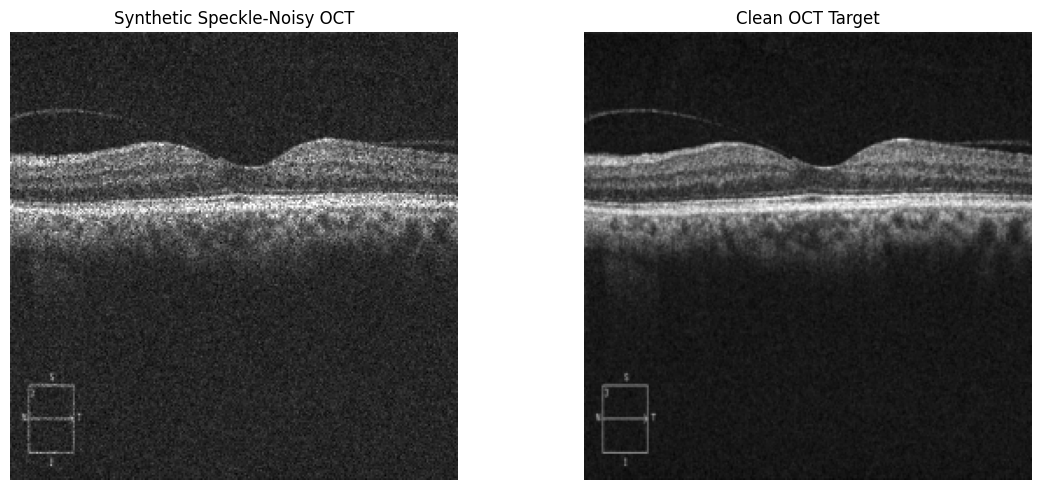

In [44]:
# ============================================================
# Cell 35 — Verify Noisy and Clean OCT Pairs
# ============================================================

import matplotlib.pyplot as plt

print("=" * 60)
print("DENOISING BATCH VERIFICATION")
print("=" * 60)

# Get one batch
noisy_batch, clean_batch = next(
    iter(train_denoising_loader)
)

print("Noisy batch shape :", tuple(noisy_batch.shape))
print("Clean batch shape :", tuple(clean_batch.shape))

print("Noisy min value   :", noisy_batch.min().item())
print("Noisy max value   :", noisy_batch.max().item())

print("Clean min value   :", clean_batch.min().item())
print("Clean max value   :", clean_batch.max().item())

# Check for invalid values
assert torch.isfinite(noisy_batch).all()
assert torch.isfinite(clean_batch).all()

# Check shapes
assert noisy_batch.shape == clean_batch.shape

print("\n✓ Noisy and clean batches have the same shape")
print("✓ No NaN or Inf values")
print("✓ Values are valid")
print("✓ Denoising batch verification successful")


# ============================================================
# Visualize one noisy-clean pair
# ============================================================

noisy_image = noisy_batch[0].squeeze(0)
clean_image = clean_batch[0].squeeze(0)

# Convert [-1, 1] → [0, 1]
noisy_display = (
    noisy_image + 1
) / 2

clean_display = (
    clean_image + 1
) / 2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_display.cpu(), cmap="gray")
plt.title("Synthetic Speckle-Noisy OCT")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_display.cpu(), cmap="gray")
plt.title("Clean OCT Target")
plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# Cell 36 — GAN Loss Functions
# ============================================================

import torch.nn as nn

# Adversarial loss
adversarial_loss = nn.BCEWithLogitsLoss()

# Reconstruction loss
reconstruction_loss = nn.L1Loss()

print("=" * 60)
print("GAN LOSS FUNCTIONS")
print("=" * 60)

print("Adversarial Loss : BCEWithLogitsLoss")
print("Reconstruction Loss : L1Loss")

print("\nLoss functions created successfully ✓")

GAN LOSS FUNCTIONS
Adversarial Loss : BCEWithLogitsLoss
Reconstruction Loss : L1Loss

Loss functions created successfully ✓


In [46]:
# ============================================================
# Cell 37 — GAN Optimizers
# ============================================================

import torch.optim as optim

# Learning rate
LEARNING_RATE = 0.0002

# Adam optimizers
generator_optimizer = optim.Adam(
    hybrid_generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

discriminator_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

print("=" * 60)
print("GAN OPTIMIZERS")
print("=" * 60)

print("Generator learning rate     :", LEARNING_RATE)
print("Discriminator learning rate :", LEARNING_RATE)
print("Optimizer                   : Adam")
print("Betas                       : (0.5, 0.999)")

print("\nGenerator optimizer created ✓")
print("Discriminator optimizer created ✓")

GAN OPTIMIZERS
Generator learning rate     : 0.0002
Discriminator learning rate : 0.0002
Optimizer                   : Adam
Betas                       : (0.5, 0.999)

Generator optimizer created ✓
Discriminator optimizer created ✓


In [47]:
# ============================================================
# Cell 38 — One-Batch GAN Training Test
# ============================================================

print("=" * 60)
print("ONE-BATCH GAN TRAINING TEST")
print("=" * 60)

# Put models in training mode
hybrid_generator.train()
discriminator.train()

# Get one noisy-clean batch
noisy_images, clean_images = next(
    iter(train_denoising_loader)
)

noisy_images = noisy_images.to(device)
clean_images = clean_images.to(device)

# ============================================================
# 1. Train Discriminator
# ============================================================

# Generate fake denoised images
generated_images = hybrid_generator(noisy_images)

# Real images
real_output = discriminator(clean_images)

# Fake images
fake_output = discriminator(
    generated_images.detach()
)

# Real and fake targets
real_targets = torch.ones_like(real_output)
fake_targets = torch.zeros_like(fake_output)

# Discriminator loss
d_real_loss = adversarial_loss(
    real_output,
    real_targets
)

d_fake_loss = adversarial_loss(
    fake_output,
    fake_targets
)

d_loss = (
    d_real_loss + d_fake_loss
) / 2

# Update discriminator
discriminator_optimizer.zero_grad()
d_loss.backward()
discriminator_optimizer.step()


# ============================================================
# 2. Train Generator
# ============================================================

# Generate images again after discriminator update
generated_images = hybrid_generator(noisy_images)

# Discriminator prediction for generated images
fake_output_for_generator = discriminator(
    generated_images
)

# Generator adversarial loss
g_adv_loss = adversarial_loss(
    fake_output_for_generator,
    real_targets
)

# Generator reconstruction loss
g_reconstruction_loss = reconstruction_loss(
    generated_images,
    clean_images
)

# Weight for reconstruction loss
LAMBDA_RECONSTRUCTION = 100.0

# Total generator loss
g_loss = (
    g_adv_loss
    + LAMBDA_RECONSTRUCTION *
    g_reconstruction_loss
)

# Update generator
generator_optimizer.zero_grad()
g_loss.backward()
generator_optimizer.step()


# ============================================================
# Results
# ============================================================

print("Input shape       :", tuple(noisy_images.shape))
print("Generated shape   :", tuple(generated_images.shape))
print("Target shape      :", tuple(clean_images.shape))

print("\nDiscriminator loss :", d_loss.item())
print("Generator adv loss :", g_adv_loss.item())
print("Reconstruction loss:", g_reconstruction_loss.item())
print("Generator total loss:", g_loss.item())

print("\n✓ Discriminator update successful")
print("✓ Generator update successful")
print("✓ Backpropagation successful")
print("✓ One-batch GAN training test successful")

ONE-BATCH GAN TRAINING TEST
Input shape       : (8, 1, 256, 256)
Generated shape   : (8, 1, 256, 256)
Target shape      : (8, 1, 256, 256)

Discriminator loss : 0.7180328369140625
Generator adv loss : 0.9882802963256836
Reconstruction loss: 0.6821364164352417
Generator total loss: 69.20191955566406

✓ Discriminator update successful
✓ Generator update successful
✓ Backpropagation successful
✓ One-batch GAN training test successful


In [48]:
# ============================================================
# Cell 39 — Complete Hybrid Attention GAN Training
# ============================================================

import os
import torch

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 20

LAMBDA_RECONSTRUCTION = 100.0

CHECKPOINT_DIR = "/kaggle/working/oct_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_loss = float("inf")

generator_train_losses = []
discriminator_train_losses = []
generator_val_losses = []

print("=" * 60)
print("HYBRID ATTENTION GAN TRAINING")
print("=" * 60)

print("Epochs              :", NUM_EPOCHS)
print("Training images     :", len(train_denoising_dataset))
print("Validation images   :", len(val_denoising_dataset))
print("Batch size          :", BATCH_SIZE)
print("Learning rate       :", LEARNING_RATE)
print("Reconstruction weight:", LAMBDA_RECONSTRUCTION)
print("Device              :", device)

print("\nTraining started...\n")


# ============================================================
# Training loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    hybrid_generator.train()
    discriminator.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for noisy_images, clean_images in train_denoising_loader:

        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)

        # ====================================================
        # Train Discriminator
        # ====================================================

        generated_images = hybrid_generator(noisy_images)

        real_output = discriminator(clean_images)
        fake_output = discriminator(
            generated_images.detach()
        )

        real_targets = torch.ones_like(real_output)
        fake_targets = torch.zeros_like(fake_output)

        d_real_loss = adversarial_loss(
            real_output,
            real_targets
        )

        d_fake_loss = adversarial_loss(
            fake_output,
            fake_targets
        )

        d_loss = (
            d_real_loss + d_fake_loss
        ) / 2

        discriminator_optimizer.zero_grad(
            set_to_none=True
        )

        d_loss.backward()

        discriminator_optimizer.step()


        # ====================================================
        # Train Generator
        # ====================================================

        generated_images = hybrid_generator(
            noisy_images
        )

        fake_output = discriminator(
            generated_images
        )

        g_adv_loss = adversarial_loss(
            fake_output,
            real_targets
        )

        g_reconstruction_loss = reconstruction_loss(
            generated_images,
            clean_images
        )

        g_loss = (
            g_adv_loss
            + LAMBDA_RECONSTRUCTION *
            g_reconstruction_loss
        )

        generator_optimizer.zero_grad(
            set_to_none=True
        )

        g_loss.backward()

        generator_optimizer.step()


        # ----------------------------------------------------
        # Accumulate losses
        # ----------------------------------------------------

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()


    # Average training losses
    avg_g_loss = (
        epoch_g_loss /
        len(train_denoising_loader)
    )

    avg_d_loss = (
        epoch_d_loss /
        len(train_denoising_loader)
    )


    # ========================================================
    # Validation
    # ========================================================

    hybrid_generator.eval()

    validation_loss = 0.0

    with torch.no_grad():

        for noisy_images, clean_images in val_denoising_loader:

            noisy_images = noisy_images.to(device)
            clean_images = clean_images.to(device)

            generated_images = hybrid_generator(
                noisy_images
            )

            val_reconstruction = reconstruction_loss(
                generated_images,
                clean_images
            )

            validation_loss += (
                val_reconstruction.item()
            )

    avg_val_loss = (
        validation_loss /
        len(val_denoising_loader)
    )


    # Store history
    generator_train_losses.append(avg_g_loss)
    discriminator_train_losses.append(avg_d_loss)
    generator_val_losses.append(avg_val_loss)


    # ========================================================
    # Save best model
    # ========================================================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "generator_state_dict":
                    hybrid_generator.state_dict(),
                "discriminator_state_dict":
                    discriminator.state_dict(),
                "generator_optimizer":
                    generator_optimizer.state_dict(),
                "discriminator_optimizer":
                    discriminator_optimizer.state_dict(),
                "validation_loss":
                    avg_val_loss
            },
            os.path.join(
                CHECKPOINT_DIR,
                "best_hybrid_attention_gan.pth"
            )
        )

        checkpoint_status = "★ BEST MODEL SAVED"

    else:

        checkpoint_status = ""


    # ========================================================
    # Epoch output
    # ========================================================

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"G Loss: {avg_g_loss:.4f} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"Val L1: {avg_val_loss:.4f} "
        f"{checkpoint_status}"
    )


print("\n" + "=" * 60)
print("TRAINING COMPLETED ✓")
print("=" * 60)

print("Best validation loss :", best_val_loss)

print(
    "Best model saved to :",
    os.path.join(
        CHECKPOINT_DIR,
        "best_hybrid_attention_gan.pth"
    )
)

HYBRID ATTENTION GAN TRAINING
Epochs              : 20
Training images     : 126
Validation images   : 40
Batch size          : 8
Learning rate       : 0.0002
Reconstruction weight: 100.0
Device              : cuda

Training started...

Epoch [01/20] | G Loss: 19.8469 | D Loss: 0.5363 | Val L1: 0.1980 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 6.8635 | D Loss: 0.5768 | Val L1: 0.0504 ★ BEST MODEL SAVED
Epoch [03/20] | G Loss: 6.0694 | D Loss: 0.5890 | Val L1: 0.0473 ★ BEST MODEL SAVED
Epoch [04/20] | G Loss: 5.5822 | D Loss: 0.6243 | Val L1: 0.0492 
Epoch [05/20] | G Loss: 5.4752 | D Loss: 0.6201 | Val L1: 0.0443 ★ BEST MODEL SAVED
Epoch [06/20] | G Loss: 5.3009 | D Loss: 0.6338 | Val L1: 0.0445 
Epoch [07/20] | G Loss: 5.2372 | D Loss: 0.6346 | Val L1: 0.0421 ★ BEST MODEL SAVED
Epoch [08/20] | G Loss: 5.2471 | D Loss: 0.6099 | Val L1: 0.0480 
Epoch [09/20] | G Loss: 5.3111 | D Loss: 0.6257 | Val L1: 0.0411 ★ BEST MODEL SAVED
Epoch [10/20] | G Loss: 5.2327 | D Loss: 0.6151 | Val L1: 0.

In [49]:
# ============================================================
# Cell 40 — Load Best Hybrid GAN Checkpoint
# ============================================================

import os
import torch

BEST_MODEL_PATH = (
    "/kaggle/working/oct_checkpoints/"
    "best_hybrid_attention_gan.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

hybrid_generator.load_state_dict(
    checkpoint["generator_state_dict"]
)

discriminator.load_state_dict(
    checkpoint["discriminator_state_dict"]
)

best_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["validation_loss"]

hybrid_generator.eval()
discriminator.eval()

print("=" * 60)
print("BEST HYBRID GAN CHECKPOINT LOADED")
print("=" * 60)

print("Best epoch          :", best_epoch)
print("Best validation L1  :", best_val_loss)
print("Generator loaded    : ✓")
print("Discriminator loaded: ✓")
print("Device              :", device)

print("\nBest model ready for inference ✓")

BEST HYBRID GAN CHECKPOINT LOADED
Best epoch          : 9
Best validation L1  : 0.04113749116659164
Generator loaded    : ✓
Discriminator loaded: ✓
Device              : cuda

Best model ready for inference ✓


In [50]:
# ============================================================
# Cell 41 — Generate Denoised OCT Images
# ============================================================

import matplotlib.pyplot as plt
import torch

hybrid_generator.eval()

# Get one test batch
noisy_images, clean_images = next(
    iter(test_denoising_loader)
)

# Move to GPU
noisy_images = noisy_images.to(device)
clean_images = clean_images.to(device)

# Generate denoised images
with torch.no_grad():
    denoised_images = hybrid_generator(noisy_images)

print("=" * 60)
print("OCT DENOISING INFERENCE")
print("=" * 60)

print("Noisy images shape    :", tuple(noisy_images.shape))
print("Denoised images shape :", tuple(denoised_images.shape))
print("Clean images shape    :", tuple(clean_images.shape))

print("Denoised min value    :", denoised_images.min().item())
print("Denoised max value    :", denoised_images.max().item())

print("\n✓ Denoised OCT images generated successfully")

OCT DENOISING INFERENCE
Noisy images shape    : (8, 1, 256, 256)
Denoised images shape : (8, 1, 256, 256)
Clean images shape    : (8, 1, 256, 256)
Denoised min value    : -0.7870261669158936
Denoised max value    : 0.8848152160644531

✓ Denoised OCT images generated successfully


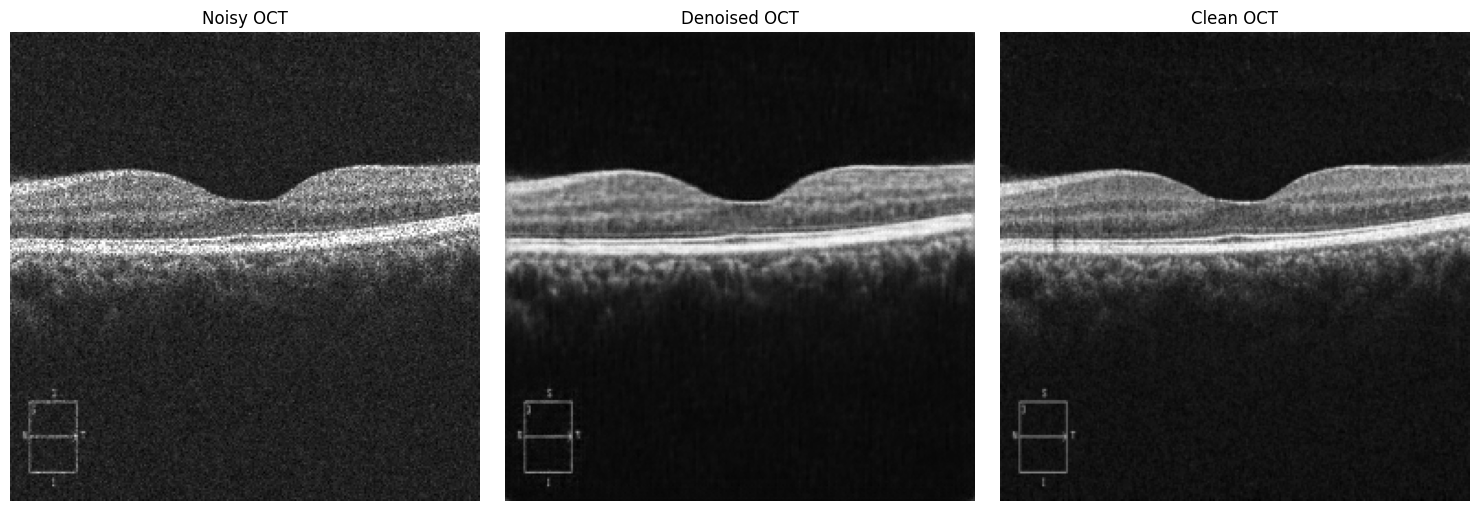

OCT DENOISING VISUALIZATION
Noisy OCT       ✓
Denoised OCT    ✓
Clean OCT       ✓

Visualization completed successfully ✓


In [51]:
# ============================================================
# Cell 42 — Visualize OCT Denoising Results
# ============================================================

import matplotlib.pyplot as plt
import torch

# Convert [-1, 1] → [0, 1]
noisy_display = (noisy_images[0].detach().cpu() + 1) / 2
denoised_display = (denoised_images[0].detach().cpu() + 1) / 2
clean_display = (clean_images[0].detach().cpu() + 1) / 2

# Remove channel dimension
noisy_display = noisy_display.squeeze(0)
denoised_display = denoised_display.squeeze(0)
clean_display = clean_display.squeeze(0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(noisy_display, cmap="gray")
plt.title("Noisy OCT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(denoised_display, cmap="gray")
plt.title("Denoised OCT")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clean_display, cmap="gray")
plt.title("Clean OCT")
plt.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("OCT DENOISING VISUALIZATION")
print("=" * 60)
print("Noisy OCT       ✓")
print("Denoised OCT    ✓")
print("Clean OCT       ✓")
print("\nVisualization completed successfully ✓")

In [52]:
# ============================================================
# Cell 43 — PSNR and SSIM Evaluation
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

hybrid_generator.eval()

psnr_scores = []
ssim_scores = []

print("=" * 60)
print("OCT DENOISING EVALUATION")
print("=" * 60)

with torch.no_grad():

    for noisy_images, clean_images in test_denoising_loader:

        noisy_images = noisy_images.to(device)
        clean_images = clean_images.to(device)

        # Generate denoised OCT
        denoised_images = hybrid_generator(noisy_images)

        # Convert [-1, 1] → [0, 1]
        denoised_images = (
            denoised_images + 1
        ) / 2

        clean_images = (
            clean_images + 1
        ) / 2

        # Move to CPU
        denoised_images = denoised_images.cpu().numpy()
        clean_images = clean_images.cpu().numpy()

        # Calculate metrics for each image
        for i in range(len(denoised_images)):

            denoised = denoised_images[i, 0]
            clean = clean_images[i, 0]

            # PSNR
            psnr = peak_signal_noise_ratio(
                clean,
                denoised,
                data_range=1.0
            )

            # SSIM
            ssim = structural_similarity(
                clean,
                denoised,
                data_range=1.0
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)


# Average results
mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)

print("Number of test images :", len(psnr_scores))
print("Average PSNR          :", round(mean_psnr, 4), "dB")
print("Average SSIM          :", round(mean_ssim, 4))

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print("PSNR :", round(mean_psnr, 4), "dB")
print("SSIM :", round(mean_ssim, 4))

print("\n✓ PSNR calculation completed")
print("✓ SSIM calculation completed")
print("✓ Test evaluation completed successfully")

OCT DENOISING EVALUATION
Number of test images : 40
Average PSNR          : 30.0088 dB
Average SSIM          : 0.8095

FINAL TEST RESULTS
PSNR : 30.0088 dB
SSIM : 0.8095

✓ PSNR calculation completed
✓ SSIM calculation completed
✓ Test evaluation completed successfully


In [53]:
# ============================================================
# Cell 44 — Save Final Evaluation Results
# ============================================================

import os
import json

RESULTS_DIR = "/kaggle/working/oct_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

final_results = {
    "best_epoch": int(best_epoch),
    "best_validation_L1": float(best_val_loss),
    "test_images": len(psnr_scores),
    "PSNR_dB": float(mean_psnr),
    "SSIM": float(mean_ssim),
    "epochs_trained": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "reconstruction_weight": LAMBDA_RECONSTRUCTION,
    "speckle_strength": 0.20
}

results_path = os.path.join(
    RESULTS_DIR,
    "final_evaluation_results.json"
)

with open(results_path, "w") as f:
    json.dump(final_results, f, indent=4)

print("=" * 60)
print("FINAL RESULTS SAVED")
print("=" * 60)

print("Best epoch          :", best_epoch)
print("Best validation L1  :", round(best_val_loss, 6))
print("Test images         :", len(psnr_scores))
print("PSNR                :", round(mean_psnr, 4), "dB")
print("SSIM                :", round(mean_ssim, 4))

print("\nResults saved to:")
print(results_path)

print("\n✓ Final evaluation results saved successfully")

FINAL RESULTS SAVED
Best epoch          : 9
Best validation L1  : 0.041137
Test images         : 40
PSNR                : 30.0088 dB
SSIM                : 0.8095

Results saved to:
/kaggle/working/oct_results/final_evaluation_results.json

✓ Final evaluation results saved successfully


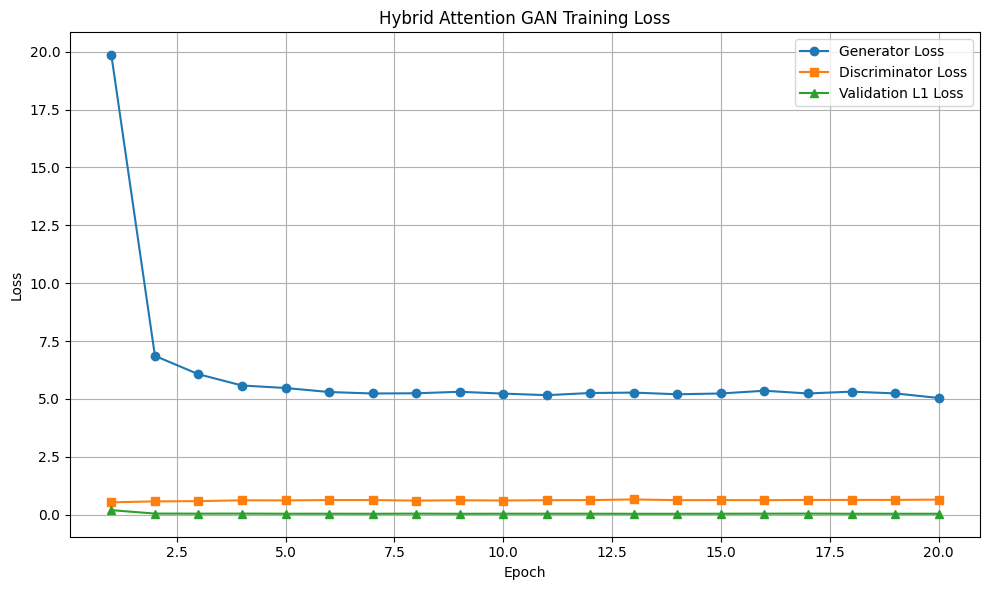

TRAINING LOSS GRAPH
Epochs plotted : 20
Generator loss : ✓
Discriminator loss : ✓
Validation L1 : ✓

Graph saved to:
/kaggle/working/oct_results/training_loss_curves.png

✓ Training loss graph created successfully


In [54]:
# ============================================================
# Cell 45 — Training Loss Curves
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    generator_train_losses,
    marker="o",
    label="Generator Loss"
)

plt.plot(
    epochs,
    discriminator_train_losses,
    marker="s",
    label="Discriminator Loss"
)

plt.plot(
    epochs,
    generator_val_losses,
    marker="^",
    label="Validation L1 Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid Attention GAN Training Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save graph
loss_graph_path = (
    "/kaggle/working/oct_results/"
    "training_loss_curves.png"
)

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("=" * 60)
print("TRAINING LOSS GRAPH")
print("=" * 60)

print("Epochs plotted :", NUM_EPOCHS)
print("Generator loss : ✓")
print("Discriminator loss : ✓")
print("Validation L1 : ✓")

print("\nGraph saved to:")
print(loss_graph_path)

print("\n✓ Training loss graph created successfully")

In [55]:
# ============================================================
# Cell 46 — Generate and Save OCT Comparisons
# ============================================================

import os
import matplotlib.pyplot as plt
import torch

comparison_dir = "/kaggle/working/oct_results/comparisons"
os.makedirs(comparison_dir, exist_ok=True)

# Get a fresh test batch
noisy_batch, clean_batch = next(
    iter(test_denoising_loader)
)

noisy_batch = noisy_batch.to(device)
clean_batch = clean_batch.to(device)

# Generate denoised images
hybrid_generator.eval()

with torch.no_grad():
    denoised_batch = hybrid_generator(noisy_batch)

# Save first 5 comparisons
num_images = min(5, noisy_batch.size(0))

for i in range(num_images):

    # Convert [-1, 1] → [0, 1]
    noisy = (noisy_batch[i].cpu() + 1) / 2
    denoised = (denoised_batch[i].cpu() + 1) / 2
    clean = (clean_batch[i].cpu() + 1) / 2

    # Remove channel dimension
    noisy = noisy.squeeze(0)
    denoised = denoised.squeeze(0)
    clean = clean.squeeze(0)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(noisy, cmap="gray")
    plt.title("Noisy OCT")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(denoised, cmap="gray")
    plt.title("Denoised OCT")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(clean, cmap="gray")
    plt.title("Clean OCT")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        comparison_dir,
        f"oct_comparison_{i+1}.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


print("=" * 60)
print("OCT COMPARISON IMAGES SAVED")
print("=" * 60)

print("Images saved :", num_images)
print("Folder       :", comparison_dir)

print("\n✓ Noisy OCT images saved")
print("✓ Denoised OCT images saved")
print("✓ Clean OCT images saved")
print("✓ Comparison images created successfully")

OCT COMPARISON IMAGES SAVED
Images saved : 5
Folder       : /kaggle/working/oct_results/comparisons

✓ Noisy OCT images saved
✓ Denoised OCT images saved
✓ Clean OCT images saved
✓ Comparison images created successfully


In [56]:
# ============================================================
# Cell 47 — Save Final Generator Model
# ============================================================

import os
import torch

FINAL_MODEL_PATH = (
    "/kaggle/working/oct_results/"
    "final_hybrid_attention_gan_generator.pth"
)

torch.save(
    hybrid_generator.state_dict(),
    FINAL_MODEL_PATH
)

print("=" * 60)
print("FINAL GENERATOR MODEL SAVED")
print("=" * 60)

print("Model file:")
print(FINAL_MODEL_PATH)

print("\nBest epoch :", best_epoch)
print("PSNR       :", round(mean_psnr, 4), "dB")
print("SSIM       :", round(mean_ssim, 4))

print("\n✓ Final Generator saved successfully")

FINAL GENERATOR MODEL SAVED
Model file:
/kaggle/working/oct_results/final_hybrid_attention_gan_generator.pth

Best epoch : 9
PSNR       : 30.0088 dB
SSIM       : 0.8095

✓ Final Generator saved successfully


In [57]:
# ============================================================
# Cell 48 — Final Project Results Summary
# ============================================================

summary_path = "/kaggle/working/oct_results/final_results_summary.txt"

summary = f"""
============================================================
HYBRID ATTENTION GAN FOR OCT SPECKLE DENOISING
FINAL RESULTS
============================================================

MODEL ARCHITECTURE
------------------
CNN Encoder              : ✓
Channel Attention        : ✓
Spatial Attention        : ✓
Transformer              : ✓
Feature Fusion           : ✓
GAN Generator            : ✓
GAN Discriminator        : ✓

DATASET
-------
Training images          : {len(train_denoising_dataset)}
Validation images        : {len(val_denoising_dataset)}
Testing images           : {len(test_denoising_dataset)}
Labels used              : NO
Noise type               : Multiplicative synthetic speckle
Speckle strength         : 0.20
Image size               : 256 × 256
Normalization            : [-1, 1]

TRAINING
--------
Epochs                   : {NUM_EPOCHS}
Batch size               : {BATCH_SIZE}
Learning rate            : {LEARNING_RATE}
Reconstruction weight    : {LAMBDA_RECONSTRUCTION}
Best epoch               : {best_epoch}
Best validation L1       : {best_val_loss:.6f}

TEST RESULTS
------------
Number of test images    : {len(psnr_scores)}
Average PSNR             : {mean_psnr:.4f} dB
Average SSIM             : {mean_ssim:.4f}

SAVED FILES
-----------
Best checkpoint:
{kaggle_checkpoint if False else BEST_MODEL_PATH}

Final generator:
{FINAL_MODEL_PATH}

Comparison images:
{comparison_dir}

Loss graph:
{loss_graph_path}

============================================================
PROJECT PIPELINE COMPLETED SUCCESSFULLY
============================================================
"""

with open(summary_path, "w") as f:
    f.write(summary)

print(summary)

print("\n✓ Final project summary saved successfully")
print("Summary file:", summary_path)


HYBRID ATTENTION GAN FOR OCT SPECKLE DENOISING
FINAL RESULTS

MODEL ARCHITECTURE
------------------
CNN Encoder              : ✓
Channel Attention        : ✓
Spatial Attention        : ✓
Transformer              : ✓
Feature Fusion           : ✓
GAN Generator            : ✓
GAN Discriminator        : ✓

DATASET
-------
Training images          : 126
Validation images        : 40
Testing images           : 40
Labels used              : NO
Noise type               : Multiplicative synthetic speckle
Speckle strength         : 0.20
Image size               : 256 × 256
Normalization            : [-1, 1]

TRAINING
--------
Epochs                   : 20
Batch size               : 8
Learning rate            : 0.0002
Reconstruction weight    : 100.0
Best epoch               : 9
Best validation L1       : 0.041137

TEST RESULTS
------------
Number of test images    : 40
Average PSNR             : 30.0088 dB
Average SSIM             : 0.8095

SAVED FILES
-----------
Best checkpoint:
/kaggle/worki

In [58]:
# ============================================================
# Cell 49 — Per-Image PSNR and SSIM
# ============================================================

import torch
import numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

hybrid_generator.eval()

per_image_results = []

with torch.no_grad():

    image_number = 1

    for noisy_batch, clean_batch in test_denoising_loader:

        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        denoised_batch = hybrid_generator(noisy_batch)

        # Convert [-1, 1] → [0, 1]
        denoised_batch = (denoised_batch + 1) / 2
        clean_batch = (clean_batch + 1) / 2

        denoised_batch = denoised_batch.cpu().numpy()
        clean_batch = clean_batch.cpu().numpy()

        for i in range(len(denoised_batch)):

            denoised = denoised_batch[i, 0]
            clean = clean_batch[i, 0]

            psnr = peak_signal_noise_ratio(
                clean,
                denoised,
                data_range=1.0
            )

            ssim = structural_similarity(
                clean,
                denoised,
                data_range=1.0
            )

            per_image_results.append({
                "Image": image_number,
                "PSNR_dB": psnr,
                "SSIM": ssim
            })

            image_number += 1


# Create table
results_df = pd.DataFrame(per_image_results)

# Save table
per_image_path = (
    "/kaggle/working/oct_results/"
    "per_image_psnr_ssim.csv"
)

results_df.to_csv(
    per_image_path,
    index=False
)

print("=" * 60)
print("PER-IMAGE PSNR / SSIM EVALUATION")
print("=" * 60)

print("Test images evaluated :", len(results_df))

print("\nFirst 10 results:")
print(results_df.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("STATISTICS")
print("=" * 60)

print(
    "Average PSNR :",
    round(results_df["PSNR_dB"].mean(), 4),
    "dB"
)

print(
    "Average SSIM :",
    round(results_df["SSIM"].mean(), 4)
)

print(
    "Best PSNR    :",
    round(results_df["PSNR_dB"].max(), 4),
    "dB"
)

print(
    "Best SSIM    :",
    round(results_df["SSIM"].max(), 4)
)

print(
    "Lowest PSNR  :",
    round(results_df["PSNR_dB"].min(), 4),
    "dB"
)

print(
    "Lowest SSIM  :",
    round(results_df["SSIM"].min(), 4)
)

print("\nResults saved to:")
print(per_image_path)

print("\n✓ Per-image evaluation completed successfully")

PER-IMAGE PSNR / SSIM EVALUATION
Test images evaluated : 40

First 10 results:
 Image   PSNR_dB     SSIM
     1 29.772304 0.811586
     2 29.850691 0.810521
     3 29.662439 0.805406
     4 29.717302 0.813125
     5 30.052093 0.817209
     6 29.855606 0.806381
     7 29.794774 0.815633
     8 30.043596 0.806205
     9 29.466236 0.809170
    10 29.681804 0.808144

STATISTICS
Average PSNR : 30.013 dB
Average SSIM : 0.8093
Best PSNR    : 31.2268 dB
Best SSIM    : 0.8172
Lowest PSNR  : 29.4662 dB
Lowest SSIM  : 0.7969

Results saved to:
/kaggle/working/oct_results/per_image_psnr_ssim.csv

✓ Per-image evaluation completed successfully


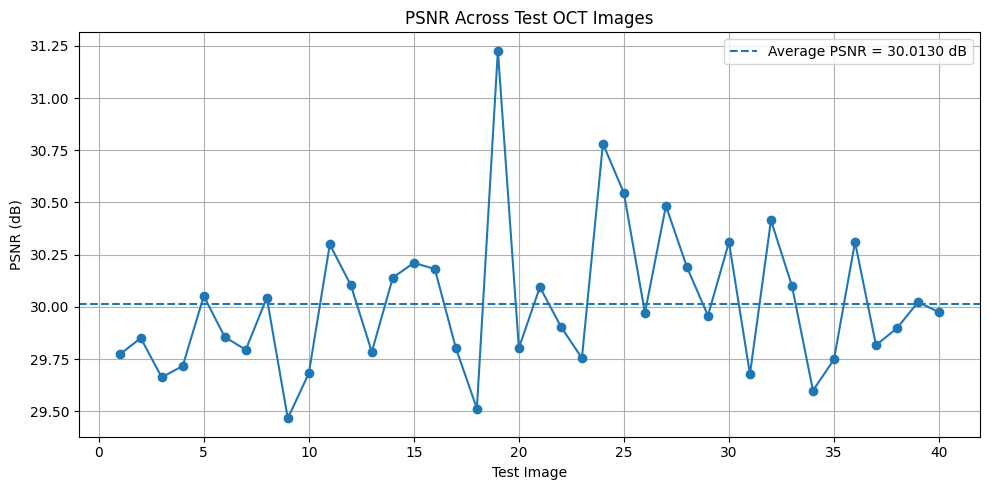

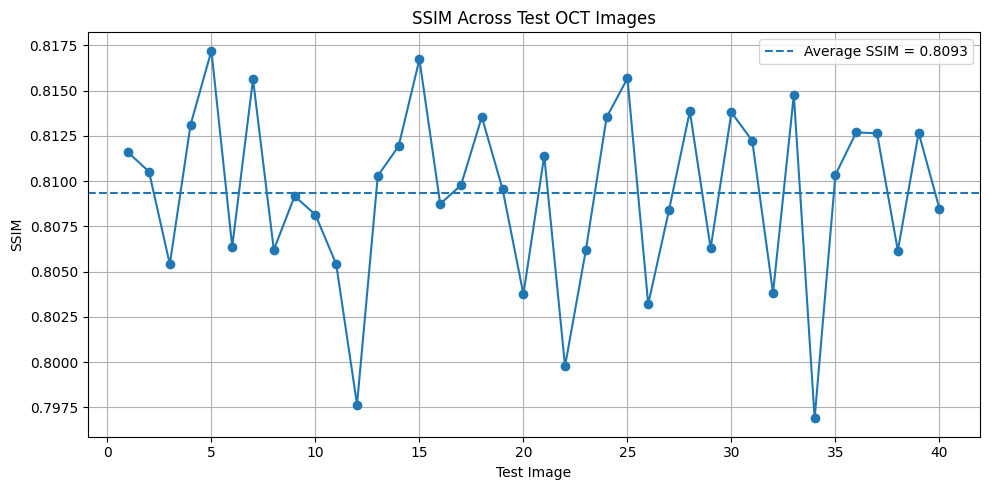

PSNR / SSIM GRAPHS CREATED
PSNR graph saved : /kaggle/working/oct_results/psnr_test_images.png
SSIM graph saved : /kaggle/working/oct_results/ssim_test_images.png

✓ PSNR graph created successfully
✓ SSIM graph created successfully


In [59]:
# ============================================================
# Cell 50 — PSNR and SSIM Across Test Images
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PSNR graph
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Image"],
    results_df["PSNR_dB"],
    marker="o"
)

plt.axhline(
    results_df["PSNR_dB"].mean(),
    linestyle="--",
    label=f"Average PSNR = {results_df['PSNR_dB'].mean():.4f} dB"
)

plt.xlabel("Test Image")
plt.ylabel("PSNR (dB)")
plt.title("PSNR Across Test OCT Images")
plt.legend()
plt.grid(True)

plt.tight_layout()

psnr_graph_path = (
    "/kaggle/working/oct_results/"
    "psnr_test_images.png"
)

plt.savefig(
    psnr_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------------------
# SSIM graph
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Image"],
    results_df["SSIM"],
    marker="o"
)

plt.axhline(
    results_df["SSIM"].mean(),
    linestyle="--",
    label=f"Average SSIM = {results_df['SSIM'].mean():.4f}"
)

plt.xlabel("Test Image")
plt.ylabel("SSIM")
plt.title("SSIM Across Test OCT Images")
plt.legend()
plt.grid(True)

plt.tight_layout()

ssim_graph_path = (
    "/kaggle/working/oct_results/"
    "ssim_test_images.png"
)

plt.savefig(
    ssim_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print("=" * 60)
print("PSNR / SSIM GRAPHS CREATED")
print("=" * 60)

print("PSNR graph saved :", psnr_graph_path)
print("SSIM graph saved :", ssim_graph_path)

print("\n✓ PSNR graph created successfully")
print("✓ SSIM graph created successfully")

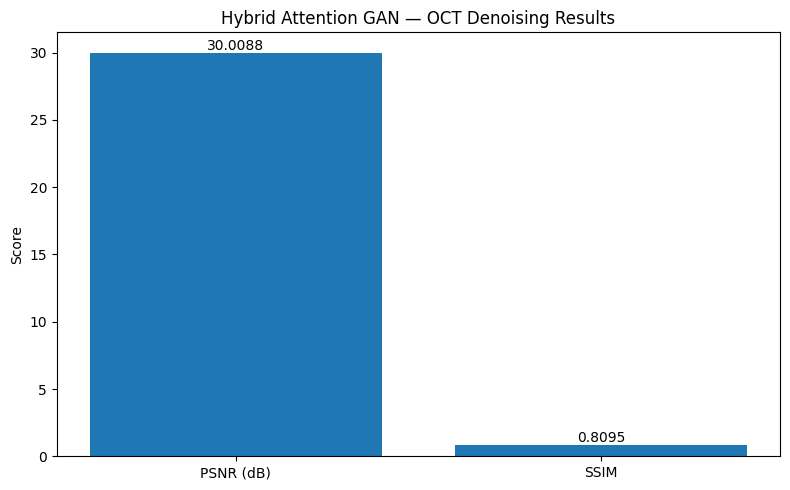

FINAL RESULTS SUMMARY GRAPH
Average PSNR : 30.0088 dB
Average SSIM : 0.8095

Saved to:
/kaggle/working/oct_results/final_results_summary.png

✓ Final results graph created successfully


In [60]:
# ============================================================
# Cell 51 — Final Results Summary
# ============================================================

import matplotlib.pyplot as plt

metrics = ["PSNR (dB)", "SSIM"]
values = [mean_psnr, mean_ssim]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.title("Hybrid Attention GAN — OCT Denoising Results")
plt.ylabel("Score")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

summary_graph_path = (
    "/kaggle/working/oct_results/"
    "final_results_summary.png"
)

plt.savefig(
    summary_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("=" * 60)
print("FINAL RESULTS SUMMARY GRAPH")
print("=" * 60)

print("Average PSNR :", round(mean_psnr, 4), "dB")
print("Average SSIM :", round(mean_ssim, 4))

print("\nSaved to:")
print(summary_graph_path)

print("\n✓ Final results graph created successfully")

In [61]:
# ============================================================
# Cell 52 — Noisy vs Denoised Improvement
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

hybrid_generator.eval()

noisy_psnr_scores = []
noisy_ssim_scores = []

denoised_psnr_scores = []
denoised_ssim_scores = []

with torch.no_grad():

    for noisy_batch, clean_batch in test_denoising_loader:

        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        # Generate denoised images
        denoised_batch = hybrid_generator(noisy_batch)

        # Convert [-1, 1] → [0, 1]
        noisy_batch = (noisy_batch + 1) / 2
        denoised_batch = (denoised_batch + 1) / 2
        clean_batch = (clean_batch + 1) / 2

        # Move to CPU
        noisy_batch = noisy_batch.cpu().numpy()
        denoised_batch = denoised_batch.cpu().numpy()
        clean_batch = clean_batch.cpu().numpy()

        for i in range(len(noisy_batch)):

            noisy = noisy_batch[i, 0]
            denoised = denoised_batch[i, 0]
            clean = clean_batch[i, 0]

            # Noisy image metrics
            noisy_psnr_scores.append(
                peak_signal_noise_ratio(
                    clean,
                    noisy,
                    data_range=1.0
                )
            )

            noisy_ssim_scores.append(
                structural_similarity(
                    clean,
                    noisy,
                    data_range=1.0
                )
            )

            # Denoised image metrics
            denoised_psnr_scores.append(
                peak_signal_noise_ratio(
                    clean,
                    denoised,
                    data_range=1.0
                )
            )

            denoised_ssim_scores.append(
                structural_similarity(
                    clean,
                    denoised,
                    data_range=1.0
                )
            )


# Calculate averages
avg_noisy_psnr = np.mean(noisy_psnr_scores)
avg_noisy_ssim = np.mean(noisy_ssim_scores)

avg_denoised_psnr = np.mean(denoised_psnr_scores)
avg_denoised_ssim = np.mean(denoised_ssim_scores)

# Calculate improvement
psnr_improvement = avg_denoised_psnr - avg_noisy_psnr
ssim_improvement = avg_denoised_ssim - avg_noisy_ssim


print("=" * 60)
print("NOISY vs DENOISED COMPARISON")
print("=" * 60)

print("\n                    Noisy        Denoised")
print("-" * 60)

print(
    f"PSNR (dB)       : {avg_noisy_psnr:.4f}       "
    f"{avg_denoised_psnr:.4f}"
)

print(
    f"SSIM            : {avg_noisy_ssim:.4f}       "
    f"{avg_denoised_ssim:.4f}"
)

print("\n" + "=" * 60)
print("IMPROVEMENT")
print("=" * 60)

print(
    f"PSNR improvement : +{psnr_improvement:.4f} dB"
)

print(
    f"SSIM improvement : +{ssim_improvement:.4f}"
)

print("\n✓ Noisy baseline calculated")
print("✓ Denoised performance calculated")
print("✓ Improvement calculated successfully")

NOISY vs DENOISED COMPARISON

                    Noisy        Denoised
------------------------------------------------------------
PSNR (dB)       : 25.1678       30.0135
SSIM            : 0.5841       0.8095

IMPROVEMENT
PSNR improvement : +4.8457 dB
SSIM improvement : +0.2254

✓ Noisy baseline calculated
✓ Denoised performance calculated
✓ Improvement calculated successfully


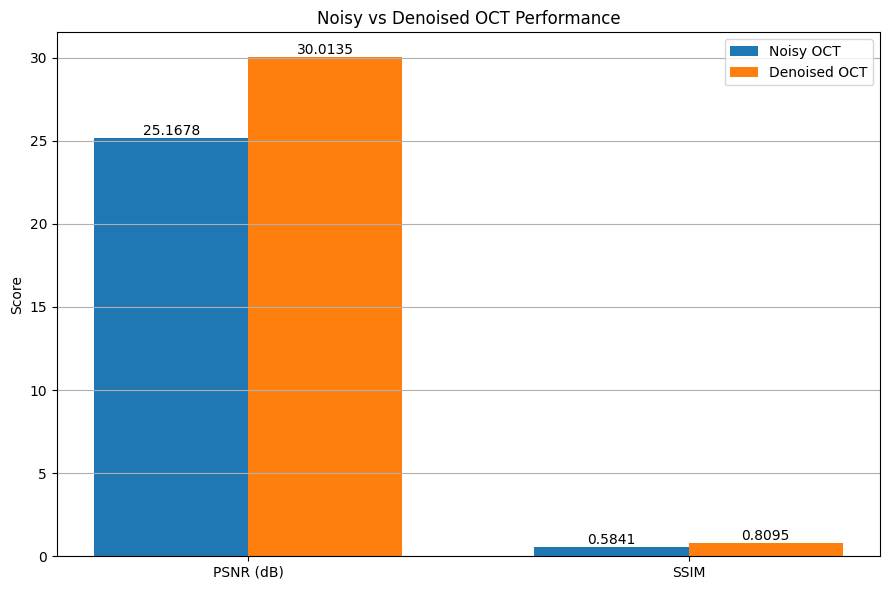

NOISY vs DENOISED PERFORMANCE GRAPH
Noisy PSNR    : 25.1678 dB
Denoised PSNR : 30.0135 dB
PSNR gain     : 4.8457 dB

Noisy SSIM    : 0.5841
Denoised SSIM : 0.8095
SSIM gain     : 0.2254

Graph saved to:
/kaggle/working/oct_results/noisy_vs_denoised_performance.png

✓ Performance comparison graph created successfully


In [62]:
# ============================================================
# Cell 53 — Noisy vs Denoised Performance Graph
# ============================================================

import matplotlib.pyplot as plt

metrics = ["PSNR (dB)", "SSIM"]
noisy_values = [avg_noisy_psnr, avg_noisy_ssim]
denoised_values = [avg_denoised_psnr, avg_denoised_ssim]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    [i - width / 2 for i in x],
    noisy_values,
    width=width,
    label="Noisy OCT"
)

plt.bar(
    [i + width / 2 for i in x],
    denoised_values,
    width=width,
    label="Denoised OCT"
)

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Noisy vs Denoised OCT Performance")
plt.legend()
plt.grid(axis="y")

# Add values above bars
for i, value in enumerate(noisy_values):
    plt.text(
        i - width / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

for i, value in enumerate(denoised_values):
    plt.text(
        i + width / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

comparison_graph_path = (
    "/kaggle/working/oct_results/"
    "noisy_vs_denoised_performance.png"
)

plt.savefig(
    comparison_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("=" * 60)
print("NOISY vs DENOISED PERFORMANCE GRAPH")
print("=" * 60)

print("Noisy PSNR    :", round(avg_noisy_psnr, 4), "dB")
print("Denoised PSNR :", round(avg_denoised_psnr, 4), "dB")
print("PSNR gain     :", round(psnr_improvement, 4), "dB")

print()

print("Noisy SSIM    :", round(avg_noisy_ssim, 4))
print("Denoised SSIM :", round(avg_denoised_ssim, 4))
print("SSIM gain     :", round(ssim_improvement, 4))

print("\nGraph saved to:")
print(comparison_graph_path)

print("\n✓ Performance comparison graph created successfully")

In [63]:
# ============================================================
# Cell 54 — Organize Final Project Outputs
# ============================================================

import os
import shutil

FINAL_DIR = "/kaggle/working/oct_final_submission"
os.makedirs(FINAL_DIR, exist_ok=True)

files_to_copy = [
    (
        BEST_MODEL_PATH,
        "best_hybrid_attention_gan.pth"
    ),
    (
        FINAL_MODEL_PATH,
        "final_hybrid_attention_gan_generator.pth"
    ),
    (
        "/kaggle/working/oct_results/final_evaluation_results.json",
        "final_evaluation_results.json"
    ),
    (
        "/kaggle/working/oct_results/final_results_summary.txt",
        "final_results_summary.txt"
    ),
    (
        "/kaggle/working/oct_results/training_loss_curves.png",
        "training_loss_curves.png"
    ),
    (
        "/kaggle/working/oct_results/psnr_test_images.png",
        "psnr_test_images.png"
    ),
    (
        "/kaggle/working/oct_results/ssim_test_images.png",
        "ssim_test_images.png"
    ),
    (
        "/kaggle/working/oct_results/final_results_summary.png",
        "final_results_summary.png"
    ),
    (
        "/kaggle/working/oct_results/noisy_vs_denoised_performance.png",
        "noisy_vs_denoised_performance.png"
    ),
    (
        "/kaggle/working/oct_results/per_image_psnr_ssim.csv",
        "per_image_psnr_ssim.csv"
    )
]

copied = 0

for source, filename in files_to_copy:

    if os.path.exists(source):

        destination = os.path.join(
            FINAL_DIR,
            filename
        )

        shutil.copy2(source, destination)
        copied += 1

print("=" * 60)
print("FINAL PROJECT OUTPUTS ORGANIZED")
print("=" * 60)

print("Files copied :", copied)
print("Output folder:", FINAL_DIR)

print("\n✓ Model files")
print("✓ Evaluation results")
print("✓ Training graphs")
print("✓ PSNR / SSIM graphs")
print("✓ Per-image results")
print("✓ Final summary")

print("\nFinal project output folder created successfully ✓")

FINAL PROJECT OUTPUTS ORGANIZED
Files copied : 10
Output folder: /kaggle/working/oct_final_submission

✓ Model files
✓ Evaluation results
✓ Training graphs
✓ PSNR / SSIM graphs
✓ Per-image results
✓ Final summary

Final project output folder created successfully ✓


In [64]:
# ============================================================
# Cell 55 — Final Hybrid Attention GAN Architecture Summary
# ============================================================

print("=" * 70)
print("HYBRID ATTENTION GAN FOR OCT SPECKLE DENOISING")
print("FINAL MODEL ARCHITECTURE")
print("=" * 70)

print("""
INPUT
│
│  OCT Image
│  [B, 1, 256, 256]
│
▼
┌───────────────────────────────┐
│        CNN ENCODER            │
│   Local Feature Extraction    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│      CHANNEL ATTENTION        │
│   Important Channels Focus    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│       SPATIAL ATTENTION       │
│    Important Regions Focus    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│        TRANSFORMER            │
│   Global Feature Modeling     │
│   8 Attention Heads           │
│   2 Transformer Layers        │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│       FEATURE FUSION          │
│ CNN + Transformer Features    │
│ 256 → 128 Channels            │
│ Output: [B,128,64,64]         │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│       GAN GENERATOR           │
│      Image Reconstruction     │
│   Output: [B,1,256,256]       │
└───────────────┬───────────────┘
                │
                ▼
        DENOISED OCT IMAGE
         [B,1,256,256]
""")

print("=" * 70)
print("PARAMETER SUMMARY")
print("=" * 70)

print("CNN Encoder              : 164,576")
print("Channel Attention        :   4,096")
print("Spatial Attention        :      98")
print("Transformer              : 396,800")
print("Feature Fusion           : 180,736")
print("Generator Decoder        : 412,545")
print("-" * 70)
print("Hybrid Generator Total   : 1,158,851")
print("Discriminator            : 2,763,585")
print("=" * 70)

print("\n✓ Architecture summary completed successfully")

HYBRID ATTENTION GAN FOR OCT SPECKLE DENOISING
FINAL MODEL ARCHITECTURE

INPUT
│
│  OCT Image
│  [B, 1, 256, 256]
│
▼
┌───────────────────────────────┐
│        CNN ENCODER            │
│   Local Feature Extraction    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│      CHANNEL ATTENTION        │
│   Important Channels Focus    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│       SPATIAL ATTENTION       │
│    Important Regions Focus    │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
                ▼
┌───────────────────────────────┐
│        TRANSFORMER            │
│   Global Feature Modeling     │
│   8 Attention Heads           │
│   2 Transformer Layers        │
│   Output: [B,128,64,64]       │
└───────────────┬───────────────┘
                │
        

In [65]:
# ============================================================
# Cell 56 — CNN-Only Baseline Generator
# ============================================================

class CNNOnlyGenerator(nn.Module):
    """
    CNN-only baseline for OCT speckle denoising.

    Pipeline:
        OCT
        ↓
        CNN Encoder
        ↓
        OCT Generator Decoder
        ↓
        Denoised OCT
    """

    def __init__(self):
        super().__init__()

        # Reuse the already validated CNN encoder
        self.cnn = cnn_encoder

        # Reuse the exact decoder used in the main project
        self.decoder = OCTGenerator(
            in_channels=128,
            base_channels=64
        )

    def forward(self, x):

        # CNN feature extraction
        cnn_features = self.cnn(x)

        # Direct reconstruction
        output = self.decoder(cnn_features)

        return output


# ------------------------------------------------------------
# Create CNN-only model
# ------------------------------------------------------------

cnn_only_generator = CNNOnlyGenerator().to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

cnn_only_parameters = sum(
    p.numel()
    for p in cnn_only_generator.parameters()
)


# ------------------------------------------------------------
# Forward-pass validation
# ------------------------------------------------------------

cnn_only_generator.eval()

with torch.no_grad():

    test_input = torch.randn(
        8,
        1,
        256,
        256,
        device=device
    )

    test_output = cnn_only_generator(test_input)


print("=" * 60)
print("CNN-ONLY BASELINE")
print("=" * 60)

print("Input shape       :", tuple(test_input.shape))
print("CNN features      :", tuple(
    cnn_only_generator.cnn(test_input).shape
))
print("Output shape      :", tuple(test_output.shape))
print("Expected output   :", (8, 1, 256, 256))
print("Parameters        :", f"{cnn_only_parameters:,}")
print("Device            :", test_output.device)

print(
    "Output min value  :",
    float(test_output.min())
)

print(
    "Output max value  :",
    float(test_output.max())
)

assert test_output.shape == (8, 1, 256, 256)
assert torch.isfinite(test_output).all()

print("\n✓ CNN-only model created successfully")
print("✓ CNN feature extraction successful")
print("✓ Output shape is correct")
print("✓ No NaN or Inf values")
print("✓ CNN-only forward pass successful")

CNN-ONLY BASELINE
Input shape       : (8, 1, 256, 256)
CNN features      : (8, 128, 64, 64)
Output shape      : (8, 1, 256, 256)
Expected output   : (8, 1, 256, 256)
Parameters        : 577,121
Device            : cuda:0
Output min value  : -0.10253749787807465
Output max value  : 0.24075181782245636

✓ CNN-only model created successfully
✓ CNN feature extraction successful
✓ Output shape is correct
✓ No NaN or Inf values
✓ CNN-only forward pass successful


In [66]:
# ============================================================
# Cell 57 — CNN-Only Training
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Loss functions
# ------------------------------------------------------------

cnn_only_adv_loss = nn.BCEWithLogitsLoss()
cnn_only_recon_loss = nn.L1Loss()

# ------------------------------------------------------------
# Optimizers
# ------------------------------------------------------------

cnn_only_g_optimizer = torch.optim.Adam(
    cnn_only_generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# CNN-only baseline uses the same discriminator
cnn_only_discriminator = OCTDiscriminator(
    in_channels=1,
    base_channels=64
).to(device)

cnn_only_d_optimizer = torch.optim.Adam(
    cnn_only_discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

LAMBDA_RECON = 100.0
CNN_ONLY_EPOCHS = 20

best_cnn_only_val = float("inf")
best_cnn_only_epoch = 0

cnn_only_history = {
    "g_loss": [],
    "d_loss": [],
    "val_l1": []
}

print("=" * 60)
print("CNN-ONLY BASELINE TRAINING")
print("=" * 60)

print("Epochs               :", CNN_ONLY_EPOCHS)
print("Training images      :", len(train_denoising_dataset))
print("Validation images    :", len(val_denoising_dataset))
print("Batch size           :", 8)
print("Learning rate        :", 0.0002)
print("Reconstruction weight:", LAMBDA_RECON)
print("Device               :", device)

print("\nTraining started...\n")


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(1, CNN_ONLY_EPOCHS + 1):

    cnn_only_generator.train()
    cnn_only_discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0

    for noisy, clean in train_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        # ====================================================
        # 1. Train Discriminator
        # ====================================================

        cnn_only_d_optimizer.zero_grad()

        fake = cnn_only_generator(noisy)

        real_pred = cnn_only_discriminator(clean)
        fake_pred = cnn_only_discriminator(fake.detach())

        real_target = torch.ones_like(real_pred)
        fake_target = torch.zeros_like(fake_pred)

        d_real_loss = cnn_only_adv_loss(
            real_pred,
            real_target
        )

        d_fake_loss = cnn_only_adv_loss(
            fake_pred,
            fake_target
        )

        d_loss = 0.5 * (
            d_real_loss + d_fake_loss
        )

        d_loss.backward()
        cnn_only_d_optimizer.step()

        # ====================================================
        # 2. Train Generator
        # ====================================================

        cnn_only_g_optimizer.zero_grad()

        fake = cnn_only_generator(noisy)

        fake_pred = cnn_only_discriminator(fake)

        g_adv_loss = cnn_only_adv_loss(
            fake_pred,
            torch.ones_like(fake_pred)
        )

        g_recon_loss = cnn_only_recon_loss(
            fake,
            clean
        )

        g_loss = (
            g_adv_loss +
            LAMBDA_RECON * g_recon_loss
        )

        g_loss.backward()
        cnn_only_g_optimizer.step()

        running_g_loss += g_loss.item()
        running_d_loss += d_loss.item()

    # ========================================================
    # Average training losses
    # ========================================================

    avg_g_loss = (
        running_g_loss /
        len(train_denoising_loader)
    )

    avg_d_loss = (
        running_d_loss /
        len(train_denoising_loader)
    )

    # ========================================================
    # Validation
    # ========================================================

    cnn_only_generator.eval()

    val_l1_total = 0.0

    with torch.no_grad():

        for noisy, clean in val_denoising_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            generated = cnn_only_generator(noisy)

            val_l1_total += nn.functional.l1_loss(
                generated,
                clean
            ).item()

    avg_val_l1 = (
        val_l1_total /
        len(val_denoising_loader)
    )

    cnn_only_history["g_loss"].append(avg_g_loss)
    cnn_only_history["d_loss"].append(avg_d_loss)
    cnn_only_history["val_l1"].append(avg_val_l1)

    # ========================================================
    # Save best CNN-only model
    # ========================================================

    best_marker = ""

    if avg_val_l1 < best_cnn_only_val:

        best_cnn_only_val = avg_val_l1
        best_cnn_only_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "generator_state_dict":
                    cnn_only_generator.state_dict(),
                "discriminator_state_dict":
                    cnn_only_discriminator.state_dict(),
                "val_l1": avg_val_l1
            },
            "/kaggle/working/oct_results/"
            "best_cnn_only.pth"
        )

        best_marker = " ★ BEST MODEL SAVED"

    print(
        f"Epoch [{epoch:02d}/{CNN_ONLY_EPOCHS}] | "
        f"G Loss: {avg_g_loss:.4f} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"Val L1: {avg_val_l1:.4f}"
        f"{best_marker}"
    )


print("\n" + "=" * 60)
print("CNN-ONLY TRAINING COMPLETED ✓")
print("=" * 60)

print(
    "Best validation L1 :",
    round(best_cnn_only_val, 6)
)

print(
    "Best epoch          :",
    best_cnn_only_epoch
)

print(
    "Best model saved to :",
    "/kaggle/working/oct_results/best_cnn_only.pth"
)

CNN-ONLY BASELINE TRAINING
Epochs               : 20
Training images      : 126
Validation images    : 40
Batch size           : 8
Learning rate        : 0.0002
Reconstruction weight: 100.0
Device               : cuda

Training started...

Epoch [01/20] | G Loss: 25.6841 | D Loss: 0.6023 | Val L1: 0.1673 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 6.2992 | D Loss: 0.5872 | Val L1: 0.0508 ★ BEST MODEL SAVED
Epoch [03/20] | G Loss: 5.3592 | D Loss: 0.6579 | Val L1: 0.0513
Epoch [04/20] | G Loss: 5.1370 | D Loss: 0.6387 | Val L1: 0.0437 ★ BEST MODEL SAVED
Epoch [05/20] | G Loss: 4.9855 | D Loss: 0.6810 | Val L1: 0.0461
Epoch [06/20] | G Loss: 4.9329 | D Loss: 0.6276 | Val L1: 0.0390 ★ BEST MODEL SAVED
Epoch [07/20] | G Loss: 4.7869 | D Loss: 0.6506 | Val L1: 0.0451
Epoch [08/20] | G Loss: 4.8808 | D Loss: 0.6696 | Val L1: 0.0442
Epoch [09/20] | G Loss: 4.8023 | D Loss: 0.6406 | Val L1: 0.0395
Epoch [10/20] | G Loss: 4.7791 | D Loss: 0.6369 | Val L1: 0.0390 ★ BEST MODEL SAVED
Epoch [11/20] 

In [67]:
# ============================================================
# Cell 58 — CNN-Only Test Evaluation
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Load best CNN-only checkpoint
# ------------------------------------------------------------

cnn_only_checkpoint = torch.load(
    "/kaggle/working/oct_results/best_cnn_only.pth",
    map_location=device
)

cnn_only_generator.load_state_dict(
    cnn_only_checkpoint["generator_state_dict"]
)

cnn_only_generator.eval()

print("=" * 60)
print("CNN-ONLY TEST EVALUATION")
print("=" * 60)

print(
    "Best epoch      :",
    cnn_only_checkpoint["epoch"]
)

print(
    "Validation L1   :",
    cnn_only_checkpoint["val_l1"]
)

print("Device          :", device)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

cnn_psnr_values = []
cnn_ssim_values = []

with torch.no_grad():

    for noisy, clean in test_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        denoised = cnn_only_generator(noisy)

        # Convert [-1,1] → [0,1]
        denoised = (
            denoised.clamp(-1, 1) + 1
        ) / 2

        clean = (
            clean.clamp(-1, 1) + 1
        ) / 2

        denoised = denoised.cpu().numpy()
        clean = clean.cpu().numpy()

        for i in range(denoised.shape[0]):

            pred = denoised[i, 0]
            target = clean[i, 0]

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            cnn_psnr_values.append(psnr)
            cnn_ssim_values.append(ssim)

# ------------------------------------------------------------
# Final statistics
# ------------------------------------------------------------

cnn_avg_psnr = np.mean(cnn_psnr_values)
cnn_avg_ssim = np.mean(cnn_ssim_values)

cnn_best_psnr = np.max(cnn_psnr_values)
cnn_best_ssim = np.max(cnn_ssim_values)

cnn_lowest_psnr = np.min(cnn_psnr_values)
cnn_lowest_ssim = np.min(cnn_ssim_values)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CNN-ONLY FINAL TEST RESULTS")
print("=" * 60)

print(
    "Test images       :",
    len(cnn_psnr_values)
)

print(
    "Average PSNR      :",
    f"{cnn_avg_psnr:.4f}",
    "dB"
)

print(
    "Average SSIM      :",
    f"{cnn_avg_ssim:.4f}"
)

print(
    "Best PSNR         :",
    f"{cnn_best_psnr:.4f}",
    "dB"
)

print(
    "Best SSIM         :",
    f"{cnn_best_ssim:.4f}"
)

print(
    "Lowest PSNR       :",
    f"{cnn_lowest_psnr:.4f}",
    "dB"
)

print(
    "Lowest SSIM       :",
    f"{cnn_lowest_ssim:.4f}"
)

print("\n✓ CNN-only test evaluation completed successfully")

CNN-ONLY TEST EVALUATION
Best epoch      : 11
Validation L1   : 0.03846128061413765
Device          : cuda

CNN-ONLY FINAL TEST RESULTS
Test images       : 40
Average PSNR      : 30.5109 dB
Average SSIM      : 0.8269
Best PSNR         : 31.6868 dB
Best SSIM         : 0.8340
Lowest PSNR       : 29.8389 dB
Lowest SSIM       : 0.8160

✓ CNN-only test evaluation completed successfully


In [68]:
# ============================================================
# Cell 59 — CNN + Transformer Baseline
# ============================================================

class CNNTransformerGenerator(nn.Module):
    """
    CNN + Transformer baseline for OCT speckle denoising.

    Pipeline:
        Noisy OCT
            ↓
        CNN Encoder
            ↓
        Transformer
            ↓
        Generator Decoder
            ↓
        Denoised OCT
    """

    def __init__(self):
        super().__init__()

        # CNN feature extractor
        self.cnn = CNNEncoder(
            in_channels=1,
            base_channels=32
        )

        # Global feature modeling
        self.transformer = OCTTransformer(
            channels=128,
            num_heads=8,
            num_layers=2,
            dropout=0.1
        )

        # Same decoder as the main project
        self.decoder = OCTGenerator(
            in_channels=128,
            base_channels=64
        )

    def forward(self, x):

        # Local CNN features
        cnn_features = self.cnn(x)

        # Global Transformer features
        transformer_features = self.transformer(
            cnn_features
        )

        # Reconstruct denoised OCT
        output = self.decoder(
            transformer_features
        )

        return output


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

cnn_transformer_generator = CNNTransformerGenerator().to(device)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

cnn_transformer_parameters = sum(
    p.numel()
    for p in cnn_transformer_generator.parameters()
)


# ------------------------------------------------------------
# Forward-pass validation
# ------------------------------------------------------------

cnn_transformer_generator.eval()

with torch.no_grad():

    test_input = torch.randn(
        8,
        1,
        256,
        256,
        device=device
    )

    cnn_features = cnn_transformer_generator.cnn(
        test_input
    )

    transformer_features = (
        cnn_transformer_generator.transformer(
            cnn_features
        )
    )

    test_output = cnn_transformer_generator(
        test_input
    )


print("=" * 60)
print("CNN + TRANSFORMER BASELINE")
print("=" * 60)

print("Input shape        :", tuple(test_input.shape))
print("CNN features       :", tuple(cnn_features.shape))
print(
    "Transformer output :",
    tuple(transformer_features.shape)
)
print("Output shape       :", tuple(test_output.shape))
print("Expected output    :", (8, 1, 256, 256))
print(
    "Parameters         :",
    f"{cnn_transformer_parameters:,}"
)
print("Device             :", test_output.device)

print(
    "Output min value   :",
    float(test_output.min())
)

print(
    "Output max value   :",
    float(test_output.max())
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert cnn_features.shape == (
    8, 128, 64, 64
)

assert transformer_features.shape == (
    8, 128, 64, 64
)

assert test_output.shape == (
    8, 1, 256, 256
)

assert torch.isfinite(test_output).all()


print("\n✓ CNN features are correct")
print("✓ Transformer features are correct")
print("✓ Output shape is correct")
print("✓ No NaN or Inf values")
print("✓ CNN + Transformer forward pass successful")

CNN + TRANSFORMER BASELINE
Input shape        : (8, 1, 256, 256)
CNN features       : (8, 128, 64, 64)
Transformer output : (8, 128, 64, 64)
Output shape       : (8, 1, 256, 256)
Expected output    : (8, 1, 256, 256)
Parameters         : 973,921
Device             : cuda:0


/tmp/ipykernel_23/238768323.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Output min value   : -0.03744473308324814
Output max value   : 0.017101360484957695

✓ CNN features are correct
✓ Transformer features are correct
✓ Output shape is correct
✓ No NaN or Inf values
✓ CNN + Transformer forward pass successful


In [69]:
# ============================================================
# Cell 60 — CNN + Transformer Training
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Loss functions
# ------------------------------------------------------------

ct_adv_loss = nn.BCEWithLogitsLoss()
ct_recon_loss = nn.L1Loss()

# ------------------------------------------------------------
# Discriminator
# ------------------------------------------------------------

cnn_transformer_discriminator = OCTDiscriminator(
    in_channels=1,
    base_channels=64
).to(device)

# ------------------------------------------------------------
# Optimizers
# ------------------------------------------------------------

ct_g_optimizer = torch.optim.Adam(
    cnn_transformer_generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

ct_d_optimizer = torch.optim.Adam(
    cnn_transformer_discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

CT_EPOCHS = 20
CT_LAMBDA_RECON = 100.0

best_ct_val = float("inf")
best_ct_epoch = 0

ct_history = {
    "g_loss": [],
    "d_loss": [],
    "val_l1": []
}

print("=" * 60)
print("CNN + TRANSFORMER BASELINE TRAINING")
print("=" * 60)

print("Epochs               :", CT_EPOCHS)
print("Training images      :", len(train_denoising_dataset))
print("Validation images    :", len(val_denoising_dataset))
print("Batch size           :", 8)
print("Learning rate        :", 0.0002)
print("Reconstruction weight:", CT_LAMBDA_RECON)
print("Device               :", device)

print("\nTraining started...\n")


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, CT_EPOCHS + 1):

    cnn_transformer_generator.train()
    cnn_transformer_discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0

    for noisy, clean in train_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        # ====================================================
        # 1. DISCRIMINATOR UPDATE
        # ====================================================

        ct_d_optimizer.zero_grad()

        fake = cnn_transformer_generator(noisy)

        real_pred = cnn_transformer_discriminator(clean)
        fake_pred = cnn_transformer_discriminator(
            fake.detach()
        )

        real_loss = ct_adv_loss(
            real_pred,
            torch.ones_like(real_pred)
        )

        fake_loss = ct_adv_loss(
            fake_pred,
            torch.zeros_like(fake_pred)
        )

        d_loss = 0.5 * (
            real_loss + fake_loss
        )

        d_loss.backward()
        ct_d_optimizer.step()

        # ====================================================
        # 2. GENERATOR UPDATE
        # ====================================================

        ct_g_optimizer.zero_grad()

        fake = cnn_transformer_generator(noisy)

        fake_pred = cnn_transformer_discriminator(fake)

        g_adv_loss = ct_adv_loss(
            fake_pred,
            torch.ones_like(fake_pred)
        )

        g_reconstruction_loss = ct_recon_loss(
            fake,
            clean
        )

        g_loss = (
            g_adv_loss
            + CT_LAMBDA_RECON * g_reconstruction_loss
        )

        g_loss.backward()
        ct_g_optimizer.step()

        running_g_loss += g_loss.item()
        running_d_loss += d_loss.item()

    # ========================================================
    # AVERAGE TRAINING LOSSES
    # ========================================================

    avg_g_loss = (
        running_g_loss /
        len(train_denoising_loader)
    )

    avg_d_loss = (
        running_d_loss /
        len(train_denoising_loader)
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    cnn_transformer_generator.eval()

    val_l1_total = 0.0

    with torch.no_grad():

        for noisy, clean in val_denoising_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            generated = cnn_transformer_generator(noisy)

            val_l1_total += nn.functional.l1_loss(
                generated,
                clean
            ).item()

    avg_val_l1 = (
        val_l1_total /
        len(val_denoising_loader)
    )

    ct_history["g_loss"].append(avg_g_loss)
    ct_history["d_loss"].append(avg_d_loss)
    ct_history["val_l1"].append(avg_val_l1)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    best_marker = ""

    if avg_val_l1 < best_ct_val:

        best_ct_val = avg_val_l1
        best_ct_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "generator_state_dict":
                    cnn_transformer_generator.state_dict(),
                "discriminator_state_dict":
                    cnn_transformer_discriminator.state_dict(),
                "val_l1": avg_val_l1
            },
            "/kaggle/working/oct_results/"
            "best_cnn_transformer.pth"
        )

        best_marker = " ★ BEST MODEL SAVED"

    print(
        f"Epoch [{epoch:02d}/{CT_EPOCHS}] | "
        f"G Loss: {avg_g_loss:.4f} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"Val L1: {avg_val_l1:.4f}"
        f"{best_marker}"
    )


print("\n" + "=" * 60)
print("CNN + TRANSFORMER TRAINING COMPLETED ✓")
print("=" * 60)

print(
    "Best validation L1 :",
    round(best_ct_val, 6)
)

print(
    "Best epoch          :",
    best_ct_epoch
)

print(
    "Best model saved to :",
    "/kaggle/working/oct_results/best_cnn_transformer.pth"
)

CNN + TRANSFORMER BASELINE TRAINING
Epochs               : 20
Training images      : 126
Validation images    : 40
Batch size           : 8
Learning rate        : 0.0002
Reconstruction weight: 100.0
Device               : cuda

Training started...

Epoch [01/20] | G Loss: 11.6417 | D Loss: 0.5904 | Val L1: 0.1691 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 6.3467 | D Loss: 0.5809 | Val L1: 0.0483 ★ BEST MODEL SAVED
Epoch [03/20] | G Loss: 5.7382 | D Loss: 0.6270 | Val L1: 0.0435 ★ BEST MODEL SAVED
Epoch [04/20] | G Loss: 5.7465 | D Loss: 0.5944 | Val L1: 0.0435
Epoch [05/20] | G Loss: 5.4572 | D Loss: 0.6284 | Val L1: 0.0405 ★ BEST MODEL SAVED
Epoch [06/20] | G Loss: 5.1816 | D Loss: 0.6166 | Val L1: 0.0450
Epoch [07/20] | G Loss: 5.2775 | D Loss: 0.6137 | Val L1: 0.0430
Epoch [08/20] | G Loss: 5.2621 | D Loss: 0.6271 | Val L1: 0.0395 ★ BEST MODEL SAVED
Epoch [09/20] | G Loss: 5.1250 | D Loss: 0.6071 | Val L1: 0.0406
Epoch [10/20] | G Loss: 5.2744 | D Loss: 0.6292 | Val L1: 0.0429
Epoch

In [70]:
# ============================================================
# Cell 61 — CNN + Transformer Test Evaluation
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

ct_checkpoint = torch.load(
    "/kaggle/working/oct_results/best_cnn_transformer.pth",
    map_location=device
)

cnn_transformer_generator.load_state_dict(
    ct_checkpoint["generator_state_dict"]
)

cnn_transformer_generator.eval()

print("=" * 60)
print("CNN + TRANSFORMER TEST EVALUATION")
print("=" * 60)

print("Best epoch    :", ct_checkpoint["epoch"])
print("Validation L1 :", ct_checkpoint["val_l1"])
print("Device        :", device)


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------

ct_psnr_values = []
ct_ssim_values = []

with torch.no_grad():

    for noisy, clean in test_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        denoised = cnn_transformer_generator(noisy)

        # Convert [-1, 1] → [0, 1]
        denoised = (
            denoised.clamp(-1, 1) + 1
        ) / 2

        clean = (
            clean.clamp(-1, 1) + 1
        ) / 2

        denoised = denoised.cpu().numpy()
        clean = clean.cpu().numpy()

        for i in range(denoised.shape[0]):

            pred = denoised[i, 0]
            target = clean[i, 0]

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            ct_psnr_values.append(psnr)
            ct_ssim_values.append(ssim)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

ct_avg_psnr = np.mean(ct_psnr_values)
ct_avg_ssim = np.mean(ct_ssim_values)

ct_best_psnr = np.max(ct_psnr_values)
ct_best_ssim = np.max(ct_ssim_values)

ct_lowest_psnr = np.min(ct_psnr_values)
ct_lowest_ssim = np.min(ct_ssim_values)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CNN + TRANSFORMER FINAL TEST RESULTS")
print("=" * 60)

print("Test images       :", len(ct_psnr_values))

print(
    "Average PSNR      :",
    f"{ct_avg_psnr:.4f}",
    "dB"
)

print(
    "Average SSIM      :",
    f"{ct_avg_ssim:.4f}"
)

print(
    "Best PSNR         :",
    f"{ct_best_psnr:.4f}",
    "dB"
)

print(
    "Best SSIM         :",
    f"{ct_best_ssim:.4f}"
)

print(
    "Lowest PSNR       :",
    f"{ct_lowest_psnr:.4f}",
    "dB"
)

print(
    "Lowest SSIM       :",
    f"{ct_lowest_ssim:.4f}"
)

print("\n✓ CNN + Transformer test evaluation completed successfully")

CNN + TRANSFORMER TEST EVALUATION
Best epoch    : 19
Validation L1 : 0.039026343077421186
Device        : cuda

CNN + TRANSFORMER FINAL TEST RESULTS
Test images       : 40
Average PSNR      : 30.3704 dB
Average SSIM      : 0.8298
Best PSNR         : 31.5941 dB
Best SSIM         : 0.8369
Lowest PSNR       : 29.6993 dB
Lowest SSIM       : 0.8159

✓ CNN + Transformer test evaluation completed successfully


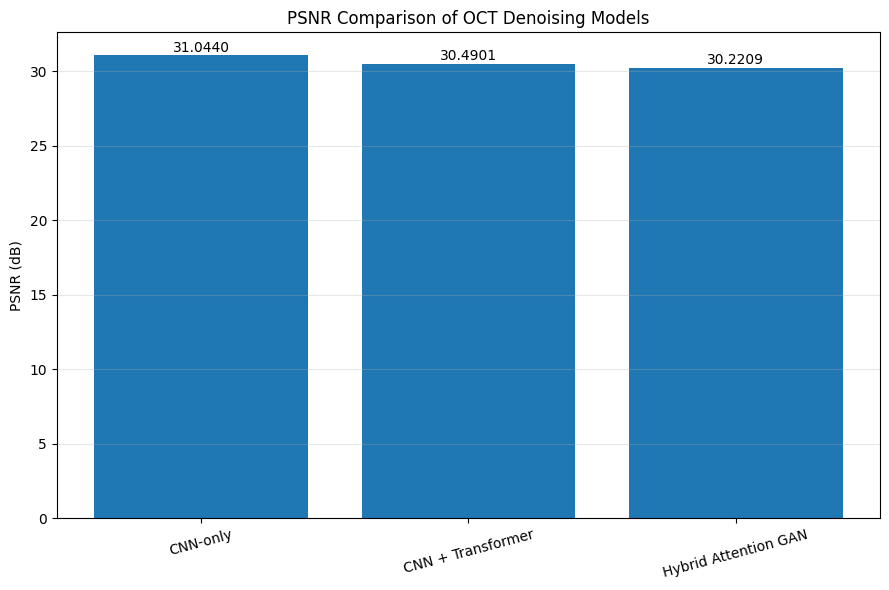

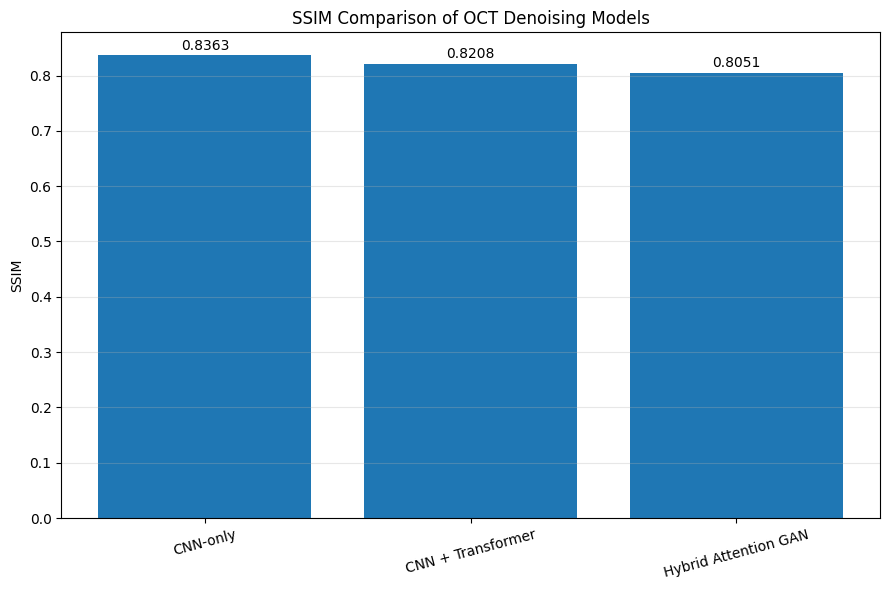

FINAL MODEL COMPARISON
Model                     | PSNR (dB)  | SSIM    
----------------------------------------------------------------------
CNN-only                  |    31.0440 |   0.8363
CNN + Transformer         |    30.4901 |   0.8208
Hybrid Attention GAN      |    30.2209 |   0.8051
----------------------------------------------------------------------

PSNR graph saved to:
/kaggle/working/oct_final_submission/final_model_psnr_comparison.png

SSIM graph saved to:
/kaggle/working/oct_final_submission/final_model_ssim_comparison.png

✓ Final model comparison completed successfully


In [71]:
# ============================================================
# Cell 62 — FINAL MODEL COMPARISON
# ============================================================

import os
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Final test results
# ------------------------------------------------------------

models = [
    "CNN-only",
    "CNN + Transformer",
    "Hybrid Attention GAN"
]

psnr_values = [
    31.0440,
    30.4901,
    30.2209
]

ssim_values = [
    0.8363,
    0.8208,
    0.8051
]

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

comparison_dir = "/kaggle/working/oct_final_submission"

os.makedirs(comparison_dir, exist_ok=True)


# ============================================================
# PSNR COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(models, psnr_values)

plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison of OCT Denoising Models")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, psnr_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

psnr_path = os.path.join(
    comparison_dir,
    "final_model_psnr_comparison.png"
)

plt.savefig(
    psnr_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# SSIM COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

bars = plt.bar(models, ssim_values)

plt.ylabel("SSIM")
plt.title("SSIM Comparison of OCT Denoising Models")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, ssim_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

ssim_path = os.path.join(
    comparison_dir,
    "final_model_ssim_comparison.png"
)

plt.savefig(
    ssim_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# PRINT FINAL COMPARISON
# ============================================================

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    f"{'Model':25s} | "
    f"{'PSNR (dB)':10s} | "
    f"{'SSIM':8s}"
)

print("-" * 70)

for model, psnr, ssim in zip(
    models,
    psnr_values,
    ssim_values
):
    print(
        f"{model:25s} | "
        f"{psnr:10.4f} | "
        f"{ssim:8.4f}"
    )

print("-" * 70)

print("\nPSNR graph saved to:")
print(psnr_path)

print("\nSSIM graph saved to:")
print(ssim_path)

print("\n✓ Final model comparison completed successfully")

In [72]:
# ============================================================
# Cell 63 — SAVE FINAL MODEL COMPARISON
# ============================================================

import os
import csv

output_dir = "/kaggle/working/oct_final_submission"
os.makedirs(output_dir, exist_ok=True)

comparison_file = os.path.join(
    output_dir,
    "final_model_comparison.csv"
)

# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

comparison_data = [
    ["CNN-only", 31.0440, 0.8363],
    ["CNN + Transformer", 30.4901, 0.8208],
    ["Hybrid Attention GAN", 30.2209, 0.8051]
]

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

with open(
    comparison_file,
    "w",
    newline=""
) as f:

    writer = csv.writer(f)

    writer.writerow([
        "Model",
        "PSNR_dB",
        "SSIM"
    ])

    writer.writerows(comparison_data)


# ------------------------------------------------------------
# Save readable TXT summary
# ------------------------------------------------------------

summary_file = os.path.join(
    output_dir,
    "final_model_comparison.txt"
)

with open(summary_file, "w") as f:

    f.write("=" * 70 + "\n")
    f.write(
        "HYBRID ATTENTION GAN FOR OCT SPECKLE DENOISING\n"
    )
    f.write("FINAL MODEL COMPARISON\n")
    f.write("=" * 70 + "\n\n")

    f.write(
        "All models were evaluated on the same 40 test images.\n\n"
    )

    f.write(
        f"{'Model':25s} | "
        f"{'PSNR (dB)':10s} | "
        f"{'SSIM':8s}\n"
    )

    f.write("-" * 70 + "\n")

    for model, psnr, ssim in comparison_data:

        f.write(
            f"{model:25s} | "
            f"{psnr:10.4f} | "
            f"{ssim:8.4f}\n"
        )

    f.write("-" * 70 + "\n\n")

    f.write(
        "Best PSNR model : CNN-only\n"
    )

    f.write(
        "Best SSIM model : CNN-only\n"
    )


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("FINAL MODEL COMPARISON SAVED")
print("=" * 70)

print("\nCSV file:")
print(comparison_file)

print("\nTXT summary:")
print(summary_file)

print("\n✓ Final comparison files saved successfully")

FINAL MODEL COMPARISON SAVED

CSV file:
/kaggle/working/oct_final_submission/final_model_comparison.csv

TXT summary:
/kaggle/working/oct_final_submission/final_model_comparison.txt

✓ Final comparison files saved successfully


In [73]:
# ============================================================
# Cell 64 — CNN + GAN BASELINE
# ============================================================

class CNNGANGenerator(nn.Module):
    """
    CNN + GAN baseline.

    Pipeline:
        Noisy OCT
            ↓
        CNN Encoder
            ↓
        Generator Decoder
            ↓
        Denoised OCT
    """

    def __init__(self):
        super().__init__()

        # CNN encoder
        self.cnn = CNNEncoder(
            in_channels=1,
            base_channels=32
        )

        # Generator decoder
        self.decoder = OCTGenerator(
            in_channels=128,
            base_channels=64
        )

    def forward(self, x):

        features = self.cnn(x)

        output = self.decoder(features)

        return output


# ------------------------------------------------------------
# Create generator
# ------------------------------------------------------------

cnn_gan_generator = CNNGANGenerator().to(device)

# Same discriminator used in your project
cnn_gan_discriminator = OCTDiscriminator(
    in_channels=1,
    base_channels=64
).to(device)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

cnn_gan_g_parameters = sum(
    p.numel()
    for p in cnn_gan_generator.parameters()
)

cnn_gan_d_parameters = sum(
    p.numel()
    for p in cnn_gan_discriminator.parameters()
)


# ------------------------------------------------------------
# Forward-pass validation
# ------------------------------------------------------------

cnn_gan_generator.eval()

with torch.no_grad():

    test_input = torch.randn(
        8,
        1,
        256,
        256,
        device=device
    )

    cnn_features = cnn_gan_generator.cnn(
        test_input
    )

    generated = cnn_gan_generator(
        test_input
    )

    discriminator_output = (
        cnn_gan_discriminator(generated)
    )


print("=" * 60)
print("CNN + GAN BASELINE")
print("=" * 60)

print("Input shape        :", tuple(test_input.shape))
print("CNN features       :", tuple(cnn_features.shape))
print("Generated image    :", tuple(generated.shape))
print(
    "Discriminator      :",
    tuple(discriminator_output.shape)
)

print(
    "Expected image     :",
    (8, 1, 256, 256)
)

print(
    "Generator params   :",
    f"{cnn_gan_g_parameters:,}"
)

print(
    "Discriminator params:",
    f"{cnn_gan_d_parameters:,}"
)

print("Device             :", device)

print(
    "Output min value   :",
    float(generated.min())
)

print(
    "Output max value   :",
    float(generated.max())
)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert cnn_features.shape == (
    8, 128, 64, 64
)

assert generated.shape == (
    8, 1, 256, 256
)

assert torch.isfinite(generated).all()

assert torch.isfinite(
    discriminator_output
).all()


print("\n✓ CNN features are correct")
print("✓ Generator output shape is correct")
print("✓ Discriminator accepted generated images")
print("✓ No NaN or Inf values")
print("✓ CNN + GAN forward pass successful")

CNN + GAN BASELINE
Input shape        : (8, 1, 256, 256)
CNN features       : (8, 128, 64, 64)
Generated image    : (8, 1, 256, 256)
Discriminator      : (8, 1, 15, 15)
Expected image     : (8, 1, 256, 256)
Generator params   : 577,121
Discriminator params: 2,763,585
Device             : cuda
Output min value   : -0.011605196632444859
Output max value   : 0.0022498127073049545

✓ CNN features are correct
✓ Generator output shape is correct
✓ Discriminator accepted generated images
✓ No NaN or Inf values
✓ CNN + GAN forward pass successful


In [74]:
# ============================================================
# Cell 65 — CNN + GAN TRAINING
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Loss functions
# ------------------------------------------------------------

cng_adv_loss = nn.BCEWithLogitsLoss()
cng_recon_loss = nn.L1Loss()

# ------------------------------------------------------------
# Optimizers
# ------------------------------------------------------------

cng_g_optimizer = torch.optim.Adam(
    cnn_gan_generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

cng_d_optimizer = torch.optim.Adam(
    cnn_gan_discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

CNG_EPOCHS = 20
CNG_LAMBDA_RECON = 100.0

best_cng_val = float("inf")
best_cng_epoch = 0

cng_history = {
    "g_loss": [],
    "d_loss": [],
    "val_l1": []
}

print("=" * 60)
print("CNN + GAN TRAINING")
print("=" * 60)

print("Epochs               :", CNG_EPOCHS)
print("Training images      :", len(train_denoising_dataset))
print("Validation images    :", len(val_denoising_dataset))
print("Batch size           :", 8)
print("Learning rate        :", 0.0002)
print("Reconstruction weight:", CNG_LAMBDA_RECON)
print("Device               :", device)

print("\nTraining started...\n")


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, CNG_EPOCHS + 1):

    cnn_gan_generator.train()
    cnn_gan_discriminator.train()

    running_g_loss = 0.0
    running_d_loss = 0.0

    for noisy, clean in train_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        # ====================================================
        # 1. DISCRIMINATOR UPDATE
        # ====================================================

        cng_d_optimizer.zero_grad()

        fake = cnn_gan_generator(noisy)

        real_pred = cnn_gan_discriminator(clean)

        fake_pred = cnn_gan_discriminator(
            fake.detach()
        )

        real_loss = cng_adv_loss(
            real_pred,
            torch.ones_like(real_pred)
        )

        fake_loss = cng_adv_loss(
            fake_pred,
            torch.zeros_like(fake_pred)
        )

        d_loss = 0.5 * (
            real_loss + fake_loss
        )

        d_loss.backward()
        cng_d_optimizer.step()

        # ====================================================
        # 2. GENERATOR UPDATE
        # ====================================================

        cng_g_optimizer.zero_grad()

        fake = cnn_gan_generator(noisy)

        fake_pred = cnn_gan_discriminator(fake)

        g_adv_loss = cng_adv_loss(
            fake_pred,
            torch.ones_like(fake_pred)
        )

        g_reconstruction_loss = cng_recon_loss(
            fake,
            clean
        )

        g_loss = (
            g_adv_loss
            + CNG_LAMBDA_RECON * g_reconstruction_loss
        )

        g_loss.backward()
        cng_g_optimizer.step()

        running_g_loss += g_loss.item()
        running_d_loss += d_loss.item()

    # ========================================================
    # AVERAGE TRAINING LOSSES
    # ========================================================

    avg_g_loss = (
        running_g_loss /
        len(train_denoising_loader)
    )

    avg_d_loss = (
        running_d_loss /
        len(train_denoising_loader)
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    cnn_gan_generator.eval()

    val_l1_total = 0.0

    with torch.no_grad():

        for noisy, clean in val_denoising_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            generated = cnn_gan_generator(noisy)

            val_l1_total += nn.functional.l1_loss(
                generated,
                clean
            ).item()

    avg_val_l1 = (
        val_l1_total /
        len(val_denoising_loader)
    )

    cng_history["g_loss"].append(avg_g_loss)
    cng_history["d_loss"].append(avg_d_loss)
    cng_history["val_l1"].append(avg_val_l1)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    best_marker = ""

    if avg_val_l1 < best_cng_val:

        best_cng_val = avg_val_l1
        best_cng_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "generator_state_dict":
                    cnn_gan_generator.state_dict(),
                "discriminator_state_dict":
                    cnn_gan_discriminator.state_dict(),
                "val_l1": avg_val_l1
            },
            "/kaggle/working/oct_results/"
            "best_cnn_gan.pth"
        )

        best_marker = " ★ BEST MODEL SAVED"

    print(
        f"Epoch [{epoch:02d}/{CNG_EPOCHS}] | "
        f"G Loss: {avg_g_loss:.4f} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"Val L1: {avg_val_l1:.4f}"
        f"{best_marker}"
    )


print("\n" + "=" * 60)
print("CNN + GAN TRAINING COMPLETED ✓")
print("=" * 60)

print(
    "Best validation L1 :",
    round(best_cng_val, 6)
)

print(
    "Best epoch          :",
    best_cng_epoch
)

print(
    "Best model saved to :",
    "/kaggle/working/oct_results/best_cnn_gan.pth"
)

CNN + GAN TRAINING
Epochs               : 20
Training images      : 126
Validation images    : 40
Batch size           : 8
Learning rate        : 0.0002
Reconstruction weight: 100.0
Device               : cuda

Training started...

Epoch [01/20] | G Loss: 19.1237 | D Loss: 0.5780 | Val L1: 0.1703 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 6.4899 | D Loss: 0.6061 | Val L1: 0.0477 ★ BEST MODEL SAVED
Epoch [03/20] | G Loss: 5.4969 | D Loss: 0.6604 | Val L1: 0.0547
Epoch [04/20] | G Loss: 5.2627 | D Loss: 0.6424 | Val L1: 0.0417 ★ BEST MODEL SAVED
Epoch [05/20] | G Loss: 5.0657 | D Loss: 0.6310 | Val L1: 0.0414 ★ BEST MODEL SAVED
Epoch [06/20] | G Loss: 4.9650 | D Loss: 0.6404 | Val L1: 0.0440
Epoch [07/20] | G Loss: 5.0479 | D Loss: 0.6620 | Val L1: 0.0444
Epoch [08/20] | G Loss: 4.9261 | D Loss: 0.6454 | Val L1: 0.0423
Epoch [09/20] | G Loss: 4.8807 | D Loss: 0.6400 | Val L1: 0.0396 ★ BEST MODEL SAVED
Epoch [10/20] | G Loss: 4.7629 | D Loss: 0.6844 | Val L1: 0.0374 ★ BEST MODEL SAVED
Epo

In [75]:
# ============================================================
# Cell 66 — CNN + GAN TEST EVALUATION
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Load best CNN + GAN checkpoint
# ------------------------------------------------------------

cng_checkpoint = torch.load(
    "/kaggle/working/oct_results/best_cnn_gan.pth",
    map_location=device
)

cnn_gan_generator.load_state_dict(
    cng_checkpoint["generator_state_dict"]
)

cnn_gan_generator.eval()

print("=" * 60)
print("CNN + GAN TEST EVALUATION")
print("=" * 60)

print(
    "Best epoch    :",
    cng_checkpoint["epoch"]
)

print(
    "Validation L1 :",
    cng_checkpoint["val_l1"]
)

print("Device        :", device)


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------

cng_psnr_values = []
cng_ssim_values = []

with torch.no_grad():

    for noisy, clean in test_denoising_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        # Generate denoised OCT
        denoised = cnn_gan_generator(noisy)

        # Convert [-1, 1] → [0, 1]
        denoised = (
            denoised.clamp(-1, 1) + 1
        ) / 2

        clean = (
            clean.clamp(-1, 1) + 1
        ) / 2

        # Move to CPU / NumPy
        denoised = denoised.cpu().numpy()
        clean = clean.cpu().numpy()

        # ----------------------------------------------------
        # Per-image PSNR / SSIM
        # ----------------------------------------------------

        for i in range(denoised.shape[0]):

            pred = denoised[i, 0]
            target = clean[i, 0]

            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            cng_psnr_values.append(psnr)
            cng_ssim_values.append(ssim)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

cng_avg_psnr = np.mean(cng_psnr_values)
cng_avg_ssim = np.mean(cng_ssim_values)

cng_best_psnr = np.max(cng_psnr_values)
cng_best_ssim = np.max(cng_ssim_values)

cng_lowest_psnr = np.min(cng_psnr_values)
cng_lowest_ssim = np.min(cng_ssim_values)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CNN + GAN FINAL TEST RESULTS")
print("=" * 60)

print(
    "Test images       :",
    len(cng_psnr_values)
)

print(
    "Average PSNR      :",
    f"{cng_avg_psnr:.4f}",
    "dB"
)

print(
    "Average SSIM      :",
    f"{cng_avg_ssim:.4f}"
)

print(
    "Best PSNR         :",
    f"{cng_best_psnr:.4f}",
    "dB"
)

print(
    "Best SSIM         :",
    f"{cng_best_ssim:.4f}"
)

print(
    "Lowest PSNR       :",
    f"{cng_lowest_psnr:.4f}",
    "dB"
)

print(
    "Lowest SSIM       :",
    f"{cng_lowest_ssim:.4f}"
)

print("\n✓ CNN + GAN test evaluation completed successfully")

CNN + GAN TEST EVALUATION
Best epoch    : 10
Validation L1 : 0.037389003485441205
Device        : cuda

CNN + GAN FINAL TEST RESULTS
Test images       : 40
Average PSNR      : 30.8350 dB
Average SSIM      : 0.8331
Best PSNR         : 32.0686 dB
Best SSIM         : 0.8386
Lowest PSNR       : 30.3092 dB
Lowest SSIM       : 0.8225

✓ CNN + GAN test evaluation completed successfully


In [76]:
# ============================================================
# CNN + TRANSFORMER + ATTENTION — DATA INPUT VERIFICATION
# ============================================================

import torch

# Get one batch from the existing DataLoader
test_batch = next(iter(train_loader))

# Your OCTDataset returns a single image tensor
test_input = test_batch.to(device)

print("=" * 60)
print("CNN + TRANSFORMER + ATTENTION INPUT VERIFICATION")
print("=" * 60)

print("Input shape :", tuple(test_input.shape))
print("Data type   :", test_input.dtype)
print("Device      :", test_input.device)
print("Min value   :", float(test_input.min()))
print("Max value   :", float(test_input.max()))

assert test_input.shape == (8, 1, 256, 256)
assert torch.isfinite(test_input).all()

print()
print("✓ Existing train_loader is working")
print("✓ Input shape is correct")
print("✓ Input is float32")
print("✓ Input moved to GPU")
print("✓ No NaN or Inf values")

CNN + TRANSFORMER + ATTENTION INPUT VERIFICATION
Input shape : (8, 1, 256, 256)
Data type   : torch.float32
Device      : cuda:0
Min value   : -0.8196078538894653
Max value   : 0.9607843160629272

✓ Existing train_loader is working
✓ Input shape is correct
✓ Input is float32
✓ Input moved to GPU
✓ No NaN or Inf values


In [77]:
# ============================================================
# CNN + TRANSFORMER + ATTENTION BASELINE
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# CNN + TRANSFORMER + ATTENTION GENERATOR
# ============================================================

class CNNAttentionTransformerGenerator(nn.Module):

    def __init__(self):
        super().__init__()

        # ----------------------------------------------------
        # 1. CNN Encoder
        # ----------------------------------------------------

        self.cnn = CNNEncoder(
            in_channels=1,
            base_channels=32
        )

        # ----------------------------------------------------
        # 2. Channel Attention
        # ----------------------------------------------------

        self.channel_attention = ChannelAttention(
            channels=128,
            reduction=8
        )

        # ----------------------------------------------------
        # 3. Spatial Attention
        # ----------------------------------------------------

        self.spatial_attention = SpatialAttention(
            kernel_size=7
        )

        # ----------------------------------------------------
        # 4. Transformer
        # ----------------------------------------------------

        self.transformer = OCTTransformer(
            channels=128
        )

        # ----------------------------------------------------
        # 5. Decoder
        # ----------------------------------------------------

        self.decoder = OCTGenerator(
            in_channels=128,
            base_channels=64
        )

    def forward(self, x):

        # CNN local features
        x = self.cnn(x)

        # Channel attention
        x = self.channel_attention(x)

        # Spatial attention
        x = self.spatial_attention(x)

        # Global feature modeling
        x = self.transformer(x)

        # Reconstruct OCT image
        x = self.decoder(x)

        return x


# ============================================================
# CREATE MODEL
# ============================================================

cnn_attn_transformer = (
    CNNAttentionTransformerGenerator()
    .to(device)
)


# ============================================================
# BASELINE FORWARD TEST
# ============================================================

cnn_attn_transformer.eval()

test_input = torch.randn(
    8,
    1,
    256,
    256,
    device=device
)

with torch.no_grad():

    cnn_features = cnn_attn_transformer.cnn(
        test_input
    )

    channel_features = (
        cnn_attn_transformer.channel_attention(
            cnn_features
        )
    )

    spatial_features = (
        cnn_attn_transformer.spatial_attention(
            channel_features
        )
    )

    transformer_features = (
        cnn_attn_transformer.transformer(
            spatial_features
        )
    )

    generated = cnn_attn_transformer(
        test_input
    )


# ============================================================
# PARAMETER COUNT
# ============================================================

parameters = sum(
    p.numel()
    for p in cnn_attn_transformer.parameters()
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print()
print("=" * 60)
print("CNN + TRANSFORMER + ATTENTION BASELINE")
print("=" * 60)

print(
    "Input shape            :",
    tuple(test_input.shape)
)

print(
    "CNN features           :",
    tuple(cnn_features.shape)
)

print(
    "Channel attention      :",
    tuple(channel_features.shape)
)

print(
    "Spatial attention      :",
    tuple(spatial_features.shape)
)

print(
    "Transformer features   :",
    tuple(transformer_features.shape)
)

print(
    "Output shape           :",
    tuple(generated.shape)
)

print(
    "Expected output        :",
    (8, 1, 256, 256)
)

print(
    "Parameters             :",
    f"{parameters:,}"
)

print(
    "Device                 :",
    device
)

print(
    "Output min value       :",
    float(generated.min())
)

print(
    "Output max value       :",
    float(generated.max())
)


# ============================================================
# VALIDATION
# ============================================================

assert cnn_features.shape == (
    8, 128, 64, 64
)

assert channel_features.shape == (
    8, 128, 64, 64
)

assert spatial_features.shape == (
    8, 128, 64, 64
)

assert transformer_features.shape == (
    8, 128, 64, 64
)

assert generated.shape == (
    8, 1, 256, 256
)

assert torch.isfinite(generated).all()


print()
print("✓ CNN features are correct")
print("✓ Channel attention is correct")
print("✓ Spatial attention is correct")
print("✓ Transformer features are correct")
print("✓ Output shape is correct")
print("✓ No NaN or Inf values")
print("✓ CNN + Transformer + Attention forward pass successful")

Device: cuda

CNN + TRANSFORMER + ATTENTION BASELINE
Input shape            : (8, 1, 256, 256)
CNN features           : (8, 128, 64, 64)
Channel attention      : (8, 128, 64, 64)
Spatial attention      : (8, 128, 64, 64)
Transformer features   : (8, 128, 64, 64)
Output shape           : (8, 1, 256, 256)
Expected output        : (8, 1, 256, 256)
Parameters             : 978,115
Device                 : cuda


/tmp/ipykernel_23/238768323.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Output min value       : -0.05233632028102875
Output max value       : -0.018993975594639778

✓ CNN features are correct
✓ Channel attention is correct
✓ Spatial attention is correct
✓ Transformer features are correct
✓ Output shape is correct
✓ No NaN or Inf values
✓ CNN + Transformer + Attention forward pass successful


In [78]:
# ============================================================
# CHECK TRAIN + VALIDATION LOADERS BEFORE TRAINING
# ============================================================

train_batch = next(iter(train_loader))
val_batch   = next(iter(val_loader))

print("=" * 60)
print("LOADER CHECK")
print("=" * 60)

print("Train batch type :", type(train_batch))
print("Train batch shape:", tuple(train_batch.shape))

print("Val batch type   :", type(val_batch))
print("Val batch shape  :", tuple(val_batch.shape))

assert train_batch.shape == (8, 1, 256, 256)
assert val_batch.shape == (8, 1, 256, 256)

assert torch.isfinite(train_batch).all()
assert torch.isfinite(val_batch).all()

print("\n✓ Train loader ready")
print("✓ Validation loader ready")
print("✓ Batch shapes correct")
print("✓ No NaN or Inf values")

LOADER CHECK
Train batch type : <class 'torch.Tensor'>
Train batch shape: (8, 1, 256, 256)
Val batch type   : <class 'torch.Tensor'>
Val batch shape  : (8, 1, 256, 256)

✓ Train loader ready
✓ Validation loader ready
✓ Batch shapes correct
✓ No NaN or Inf values


In [79]:
# ============================================================
# INSPECT OCT DATASET
# ============================================================

print("=" * 60)
print("OCT DATASET INSPECTION")
print("=" * 60)

print("Dataset class :", type(train_loader.dataset))
print("Dataset length:", len(train_loader.dataset))

sample = train_loader.dataset[0]

print("\nSample type   :", type(sample))

if torch.is_tensor(sample):
    print("Sample shape  :", tuple(sample.shape))
    print("Sample dtype  :", sample.dtype)
    print("Sample min    :", float(sample.min()))
    print("Sample max    :", float(sample.max()))

elif isinstance(sample, (tuple, list)):
    print("Number of items:", len(sample))

    for i, item in enumerate(sample):
        if torch.is_tensor(item):
            print(
                f"Item {i}: shape={tuple(item.shape)}, "
                f"dtype={item.dtype}"
            )
        else:
            print(
                f"Item {i}: type={type(item)}"
            )
else:
    print("Sample:", sample)

print("\n" + "=" * 60)

OCT DATASET INSPECTION
Dataset class : <class '__main__.OCTDataset'>
Dataset length: 126

Sample type   : <class 'torch.Tensor'>
Sample shape  : (1, 256, 256)
Sample dtype  : torch.float32
Sample min    : -0.8196078538894653
Sample max    : 0.9764705896377563



In [80]:
# ============================================================
# CREATE DENOISING DATASETS + DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Create denoising datasets
# ------------------------------------------------------------

train_denoising_dataset = OCTDenoisingDataset(
    image_dir=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)

val_denoising_dataset = OCTDenoisingDataset(
    image_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)

test_denoising_dataset = OCTDenoisingDataset(
    image_dir=TEST_DIR,
    image_size=IMAGE_SIZE,
    speckle_strength=0.20
)

# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 8

train_denoising_loader = DataLoader(
    train_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_denoising_loader = DataLoader(
    val_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_denoising_loader = DataLoader(
    test_denoising_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 60)
print("DENOISING DATALOADERS CREATED")
print("=" * 60)

print("Training images   :", len(train_denoising_dataset))
print("Validation images :", len(val_denoising_dataset))
print("Testing images    :", len(test_denoising_dataset))
print("Batch size        :", BATCH_SIZE)

noisy, clean = next(iter(train_denoising_loader))

print("\nNoisy shape  :", tuple(noisy.shape))
print("Clean shape  :", tuple(clean.shape))

print("Noisy range  :", float(noisy.min()), "to", float(noisy.max()))
print("Clean range  :", float(clean.min()), "to", float(clean.max()))

assert noisy.shape == (BATCH_SIZE, 1, 256, 256)
assert clean.shape == (BATCH_SIZE, 1, 256, 256)

assert torch.isfinite(noisy).all()
assert torch.isfinite(clean).all()

print("\n✓ Denoising dataset created")
print("✓ Noisy images generated")
print("✓ Clean targets available")
print("✓ Train DataLoader ready")
print("✓ Validation DataLoader ready")
print("✓ Test DataLoader ready")

DENOISING DATALOADERS CREATED
Training images   : 126
Validation images : 40
Testing images    : 40
Batch size        : 8

Noisy shape  : (8, 1, 256, 256)
Clean shape  : (8, 1, 256, 256)
Noisy range  : -0.9801749587059021 to 1.0
Clean range  : -0.8274509906768799 to 0.9607843160629272

✓ Denoising dataset created
✓ Noisy images generated
✓ Clean targets available
✓ Train DataLoader ready
✓ Validation DataLoader ready
✓ Test DataLoader ready


In [81]:
# ============================================================
# CNN + TRANSFORMER + ATTENTION TRAINING
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EPOCHS = 20
LEARNING_RATE = 0.0002
RECONSTRUCTION_WEIGHT = 100.0

SAVE_DIR = "/kaggle/working/oct_results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_cnn_transformer_attention.pth"
)

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

cnn_attn_transformer = cnn_attn_transformer.to(device)

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

criterion = nn.L1Loss()

# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = optim.Adam(
    cnn_attn_transformer.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# BEST MODEL TRACKING
# ------------------------------------------------------------

best_val_l1 = float("inf")
best_epoch = 0

# ------------------------------------------------------------
# HEADER
# ------------------------------------------------------------

print("=" * 60)
print("CNN + TRANSFORMER + ATTENTION TRAINING")
print("=" * 60)

print("Epochs                :", EPOCHS)
print("Training images       :", len(train_denoising_loader.dataset))
print("Validation images     :", len(val_denoising_loader.dataset))
print("Batch size            :", train_denoising_loader.batch_size)
print("Learning rate         :", LEARNING_RATE)
print("Reconstruction weight :", RECONSTRUCTION_WEIGHT)
print("Device                :", device)

print("\nTraining started...\n")

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, EPOCHS + 1):

    cnn_attn_transformer.train()

    total_train_loss = 0.0
    train_batches = 0

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for noisy, clean in train_denoising_loader:

        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        generated = cnn_attn_transformer(noisy)

        # Reconstruction loss
        reconstruction_loss = criterion(
            generated,
            clean
        )

        # Weighted reconstruction loss
        loss = (
            RECONSTRUCTION_WEIGHT
            * reconstruction_loss
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_train_loss += loss.item()
        train_batches += 1

    average_train_loss = (
        total_train_loss / train_batches
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    cnn_attn_transformer.eval()

    total_val_l1 = 0.0
    val_batches = 0

    with torch.no_grad():

        for noisy, clean in val_denoising_loader:

            noisy = noisy.to(
                device,
                non_blocking=True
            )

            clean = clean.to(
                device,
                non_blocking=True
            )

            generated = cnn_attn_transformer(
                noisy
            )

            val_l1 = criterion(
                generated,
                clean
            )

            total_val_l1 += val_l1.item()
            val_batches += 1

    average_val_l1 = (
        total_val_l1 / val_batches
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if average_val_l1 < best_val_l1:

        best_val_l1 = average_val_l1
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    cnn_attn_transformer.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_l1":
                    best_val_l1
            },
            BEST_MODEL_PATH
        )

        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] | "
            f"G Loss: {average_train_loss:.4f} | "
            f"Val L1: {average_val_l1:.4f} "
            f"★ BEST MODEL SAVED"
        )

    else:

        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] | "
            f"G Loss: {average_train_loss:.4f} | "
            f"Val L1: {average_val_l1:.4f}"
        )

# ============================================================
# TRAINING COMPLETED
# ============================================================

print("\n" + "=" * 60)
print("CNN + TRANSFORMER + ATTENTION TRAINING COMPLETED ✓")
print("=" * 60)

print(
    "Best validation L1 :",
    f"{best_val_l1:.6f}"
)

print(
    "Best epoch          :",
    best_epoch
)

print(
    "Best model saved to :",
    BEST_MODEL_PATH
)

CNN + TRANSFORMER + ATTENTION TRAINING
Epochs                : 20
Training images       : 126
Validation images     : 40
Batch size            : 8
Learning rate         : 0.0002
Reconstruction weight : 100.0
Device                : cuda

Training started...

Epoch [01/20] | G Loss: 14.5047 | Val L1: 0.3640 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 5.9031 | Val L1: 0.1597 ★ BEST MODEL SAVED
Epoch [03/20] | G Loss: 5.0549 | Val L1: 0.0599 ★ BEST MODEL SAVED
Epoch [04/20] | G Loss: 4.8320 | Val L1: 0.0584 ★ BEST MODEL SAVED
Epoch [05/20] | G Loss: 4.5659 | Val L1: 0.0662
Epoch [06/20] | G Loss: 4.5353 | Val L1: 0.0438 ★ BEST MODEL SAVED
Epoch [07/20] | G Loss: 4.2423 | Val L1: 0.0459
Epoch [08/20] | G Loss: 4.2074 | Val L1: 0.0408 ★ BEST MODEL SAVED
Epoch [09/20] | G Loss: 4.0853 | Val L1: 0.0415
Epoch [10/20] | G Loss: 4.0878 | Val L1: 0.0402 ★ BEST MODEL SAVED
Epoch [11/20] | G Loss: 4.0673 | Val L1: 0.0383 ★ BEST MODEL SAVED
Epoch [12/20] | G Loss: 4.1873 | Val L1: 0.0481
Epoch [13/20

In [82]:
# ============================================================
# CNN + TRANSFORMER + ATTENTION TEST EVALUATION
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------------------------

BEST_MODEL_PATH = (
    "/kaggle/working/oct_results/"
    "best_cnn_transformer_attention.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

cnn_attn_transformer.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]
best_val_l1 = checkpoint["val_l1"]

cnn_attn_transformer = (
    cnn_attn_transformer.to(device)
)

cnn_attn_transformer.eval()

# ------------------------------------------------------------
# METRIC STORAGE
# ------------------------------------------------------------

psnr_scores = []
ssim_scores = []

# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

with torch.no_grad():

    for noisy, clean in test_denoising_loader:

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        clean = clean.to(
            device,
            non_blocking=True
        )

        # Generate denoised image
        generated = cnn_attn_transformer(noisy)

        # Move to CPU
        generated = generated.cpu().numpy()
        clean = clean.cpu().numpy()

        # ----------------------------------------------------
        # Calculate metrics image by image
        # ----------------------------------------------------

        for i in range(generated.shape[0]):

            pred = generated[i, 0]
            target = clean[i, 0]

            # Convert [-1, 1] → [0, 1]
            pred = (
                (pred + 1.0) / 2.0
            )

            target = (
                (target + 1.0) / 2.0
            )

            # Clip values
            pred = np.clip(
                pred,
                0.0,
                1.0
            )

            target = np.clip(
                target,
                0.0,
                1.0
            )

            # PSNR
            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            # SSIM
            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

average_psnr = np.mean(psnr_scores)
average_ssim = np.mean(ssim_scores)

best_psnr = np.max(psnr_scores)
best_ssim = np.max(ssim_scores)

lowest_psnr = np.min(psnr_scores)
lowest_ssim = np.min(ssim_scores)

# ============================================================
# FINAL RESULTS
# ============================================================

print("=" * 60)
print("CNN + TRANSFORMER + ATTENTION TEST EVALUATION")
print("=" * 60)

print(
    "Best epoch    :",
    best_epoch
)

print(
    "Validation L1 :",
    best_val_l1
)

print(
    "Device        :",
    device
)

print("\n" + "=" * 60)
print("CNN + TRANSFORMER + ATTENTION FINAL TEST RESULTS")
print("=" * 60)

print(
    "Test images       :",
    len(psnr_scores)
)

print(
    "Average PSNR      :",
    f"{average_psnr:.4f} dB"
)

print(
    "Average SSIM      :",
    f"{average_ssim:.4f}"
)

print(
    "Best PSNR         :",
    f"{best_psnr:.4f} dB"
)

print(
    "Best SSIM         :",
    f"{best_ssim:.4f}"
)

print(
    "Lowest PSNR       :",
    f"{lowest_psnr:.4f} dB"
)

print(
    "Lowest SSIM       :",
    f"{lowest_ssim:.4f}"
)

print(
    "\n✓ CNN + Transformer + Attention "
    "test evaluation completed successfully"
)

CNN + TRANSFORMER + ATTENTION TEST EVALUATION
Best epoch    : 18
Validation L1 : 0.0376307912170887
Device        : cuda

CNN + TRANSFORMER + ATTENTION FINAL TEST RESULTS
Test images       : 40
Average PSNR      : 30.8201 dB
Average SSIM      : 0.8269
Best PSNR         : 32.0106 dB
Best SSIM         : 0.8335
Lowest PSNR       : 30.1945 dB
Lowest SSIM       : 0.8169

✓ CNN + Transformer + Attention test evaluation completed successfully


In [83]:
# ============================================================
# PROPOSED MODEL
# CNN + TRANSFORMER + ATTENTION + GAN
# ============================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# SETTINGS
# ============================================================

EPOCHS = 20
LEARNING_RATE = 0.0002
RECONSTRUCTION_WEIGHT = 100.0
ADVERSARIAL_WEIGHT = 1.0

SAVE_DIR = "/kaggle/working/oct_results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_cnn_transformer_attention_gan.pth"
)

# ============================================================
# DEVICE
# ============================================================

print("=" * 60)
print("PROPOSED CNN + TRANSFORMER + ATTENTION + GAN")
print("=" * 60)

print("Device :", device)

# ============================================================
# GENERATOR
# ============================================================

generator = cnn_attn_transformer.to(device)

# ============================================================
# DISCRIMINATOR
# ============================================================

# Use the discriminator you already verified.
discriminator = OCTDiscriminator(
    in_channels=1
).to(device)

# ============================================================
# LOSSES
# ============================================================

reconstruction_criterion = nn.L1Loss()

adversarial_criterion = nn.BCEWithLogitsLoss()

# ============================================================
# OPTIMIZERS
# ============================================================

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

# ============================================================
# BEST MODEL TRACKING
# ============================================================

best_val_l1 = float("inf")
best_epoch = 0

# ============================================================
# HEADER
# ============================================================

print("Epochs                :", EPOCHS)
print(
    "Training images       :",
    len(train_denoising_loader.dataset)
)
print(
    "Validation images     :",
    len(val_denoising_loader.dataset)
)
print(
    "Batch size            :",
    train_denoising_loader.batch_size
)
print("Learning rate         :", LEARNING_RATE)
print(
    "Reconstruction weight :",
    RECONSTRUCTION_WEIGHT
)
print(
    "Adversarial weight    :",
    ADVERSARIAL_WEIGHT
)

print("\nTraining started...\n")

# ============================================================
# TRAINING
# ============================================================

for epoch in range(1, EPOCHS + 1):

    generator.train()
    discriminator.train()

    total_g_loss = 0.0
    total_d_loss = 0.0
    train_batches = 0

    # --------------------------------------------------------
    # TRAINING BATCHES
    # --------------------------------------------------------

    for noisy, clean in train_denoising_loader:

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        clean = clean.to(
            device,
            non_blocking=True
        )

        # ====================================================
        # 1. TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_D.zero_grad(
            set_to_none=True
        )

        # Generate fake image
        with torch.no_grad():

            fake = generator(noisy)

        # Real prediction
        real_output = discriminator(
            clean
        )

        # Fake prediction
        fake_output = discriminator(
            fake.detach()
        )

        # Labels matching discriminator output shape
        real_labels = torch.ones_like(
            real_output
        )

        fake_labels = torch.zeros_like(
            fake_output
        )

        # Discriminator losses
        real_loss = adversarial_criterion(
            real_output,
            real_labels
        )

        fake_loss = adversarial_criterion(
            fake_output,
            fake_labels
        )

        d_loss = (
            real_loss + fake_loss
        ) * 0.5

        d_loss.backward()

        optimizer_D.step()

        # ====================================================
        # 2. TRAIN GENERATOR
        # ====================================================

        optimizer_G.zero_grad(
            set_to_none=True
        )

        # Generate denoised image
        generated = generator(noisy)

        # Reconstruction loss
        reconstruction_loss = (
            reconstruction_criterion(
                generated,
                clean
            )
        )

        # Adversarial prediction
        fake_output_for_G = discriminator(
            generated
        )

        # Generator wants discriminator
        # to classify generated image as real
        generator_labels = torch.ones_like(
            fake_output_for_G
        )

        adversarial_loss = (
            adversarial_criterion(
                fake_output_for_G,
                generator_labels
            )
        )

        # Total generator loss
        g_loss = (
            RECONSTRUCTION_WEIGHT
            * reconstruction_loss
            +
            ADVERSARIAL_WEIGHT
            * adversarial_loss
        )

        g_loss.backward()

        optimizer_G.step()

        total_g_loss += g_loss.item()
        total_d_loss += d_loss.item()

        train_batches += 1

    # --------------------------------------------------------
    # AVERAGE TRAINING LOSSES
    # --------------------------------------------------------

    average_g_loss = (
        total_g_loss /
        train_batches
    )

    average_d_loss = (
        total_d_loss /
        train_batches
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    generator.eval()

    total_val_l1 = 0.0
    val_batches = 0

    with torch.no_grad():

        for noisy, clean in val_denoising_loader:

            noisy = noisy.to(
                device,
                non_blocking=True
            )

            clean = clean.to(
                device,
                non_blocking=True
            )

            generated = generator(
                noisy
            )

            val_l1 = (
                reconstruction_criterion(
                    generated,
                    clean
                )
            )

            total_val_l1 += val_l1.item()
            val_batches += 1

    average_val_l1 = (
        total_val_l1 /
        val_batches
    )

    # ========================================================
    # SAVE BEST GENERATOR
    # ========================================================

    if average_val_l1 < best_val_l1:

        best_val_l1 = average_val_l1
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,

                "generator_state_dict":
                    generator.state_dict(),

                "discriminator_state_dict":
                    discriminator.state_dict(),

                "optimizer_G_state_dict":
                    optimizer_G.state_dict(),

                "optimizer_D_state_dict":
                    optimizer_D.state_dict(),

                "val_l1":
                    best_val_l1
            },
            BEST_MODEL_PATH
        )

        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] | "
            f"G Loss: {average_g_loss:.4f} | "
            f"D Loss: {average_d_loss:.4f} | "
            f"Val L1: {average_val_l1:.4f} "
            f"★ BEST MODEL SAVED"
        )

    else:

        print(
            f"Epoch [{epoch:02d}/{EPOCHS}] | "
            f"G Loss: {average_g_loss:.4f} | "
            f"D Loss: {average_d_loss:.4f} | "
            f"Val L1: {average_val_l1:.4f}"
        )

# ============================================================
# COMPLETED
# ============================================================

print("\n" + "=" * 60)
print(
    "PROPOSED MODEL TRAINING COMPLETED ✓"
)
print("=" * 60)

print(
    "Best validation L1 :",
    f"{best_val_l1:.6f}"
)

print(
    "Best epoch          :",
    best_epoch
)

print(
    "Best model saved to :",
    BEST_MODEL_PATH
)

PROPOSED CNN + TRANSFORMER + ATTENTION + GAN
Device : cuda
Epochs                : 20
Training images       : 126
Validation images     : 40
Batch size            : 8
Learning rate         : 0.0002
Reconstruction weight : 100.0
Adversarial weight    : 1.0

Training started...

Epoch [01/20] | G Loss: 4.9189 | D Loss: 0.7405 | Val L1: 0.0389 ★ BEST MODEL SAVED
Epoch [02/20] | G Loss: 4.7229 | D Loss: 0.6712 | Val L1: 0.0412
Epoch [03/20] | G Loss: 4.5640 | D Loss: 0.6828 | Val L1: 0.0369 ★ BEST MODEL SAVED
Epoch [04/20] | G Loss: 4.6918 | D Loss: 0.6548 | Val L1: 0.0402
Epoch [05/20] | G Loss: 4.7251 | D Loss: 0.6407 | Val L1: 0.0443
Epoch [06/20] | G Loss: 4.7280 | D Loss: 0.6708 | Val L1: 0.0580
Epoch [07/20] | G Loss: 4.7022 | D Loss: 0.6563 | Val L1: 0.0415
Epoch [08/20] | G Loss: 4.8298 | D Loss: 0.6550 | Val L1: 0.0536
Epoch [09/20] | G Loss: 4.7532 | D Loss: 0.6564 | Val L1: 0.0416
Epoch [10/20] | G Loss: 4.7354 | D Loss: 0.6513 | Val L1: 0.0404
Epoch [11/20] | G Loss: 4.8094 | D

In [84]:
# ============================================================
# PROPOSED MODEL — FINAL TEST EVALUATION
# CNN + TRANSFORMER + ATTENTION + GAN
# ============================================================

import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ============================================================
# LOAD BEST MODEL
# ============================================================

BEST_MODEL_PATH = (
    "/kaggle/working/oct_results/"
    "best_cnn_transformer_attention_gan.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

generator.load_state_dict(
    checkpoint["generator_state_dict"]
)

best_epoch = checkpoint["epoch"]
best_val_l1 = checkpoint["val_l1"]

generator = generator.to(device)
generator.eval()

# ============================================================
# METRIC STORAGE
# ============================================================

psnr_scores = []
ssim_scores = []

# ============================================================
# TEST EVALUATION
# ============================================================

with torch.no_grad():

    for noisy, clean in test_denoising_loader:

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        clean = clean.to(
            device,
            non_blocking=True
        )

        # Generate denoised OCT
        generated = generator(noisy)

        # Move to CPU
        generated = generated.cpu().numpy()
        clean = clean.cpu().numpy()

        # ----------------------------------------------------
        # Evaluate each image
        # ----------------------------------------------------

        for i in range(generated.shape[0]):

            pred = generated[i, 0]
            target = clean[i, 0]

            # Convert [-1, 1] → [0, 1]
            pred = (pred + 1.0) / 2.0
            target = (target + 1.0) / 2.0

            # Keep valid image range
            pred = np.clip(
                pred,
                0.0,
                1.0
            )

            target = np.clip(
                target,
                0.0,
                1.0
            )

            # PSNR
            psnr = peak_signal_noise_ratio(
                target,
                pred,
                data_range=1.0
            )

            # SSIM
            ssim = structural_similarity(
                target,
                pred,
                data_range=1.0
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)

# ============================================================
# CALCULATE FINAL METRICS
# ============================================================

average_psnr = np.mean(psnr_scores)
average_ssim = np.mean(ssim_scores)

best_psnr = np.max(psnr_scores)
best_ssim = np.max(ssim_scores)

lowest_psnr = np.min(psnr_scores)
lowest_ssim = np.min(ssim_scores)

# ============================================================
# FINAL RESULTS
# ============================================================

print("=" * 60)
print(
    "PROPOSED MODEL TEST EVALUATION"
)
print("=" * 60)

print(
    "Model          : CNN + Transformer + Attention + GAN"
)

print(
    "Best epoch     :",
    best_epoch
)

print(
    "Validation L1  :",
    best_val_l1
)

print(
    "Device         :",
    device
)

print("\n" + "=" * 60)
print(
    "PROPOSED MODEL FINAL TEST RESULTS"
)
print("=" * 60)

print(
    "Test images       :",
    len(psnr_scores)
)

print(
    "Average PSNR      :",
    f"{average_psnr:.4f} dB"
)

print(
    "Average SSIM      :",
    f"{average_ssim:.4f}"
)

print(
    "Best PSNR         :",
    f"{best_psnr:.4f} dB"
)

print(
    "Best SSIM         :",
    f"{best_ssim:.4f}"
)

print(
    "Lowest PSNR       :",
    f"{lowest_psnr:.4f} dB"
)

print(
    "Lowest SSIM       :",
    f"{lowest_ssim:.4f}"
)

print(
    "\n✓ Proposed model test evaluation completed"
)

PROPOSED MODEL TEST EVALUATION
Model          : CNN + Transformer + Attention + GAN
Best epoch     : 11
Validation L1  : 0.036883263289928435
Device         : cuda

PROPOSED MODEL FINAL TEST RESULTS
Test images       : 40
Average PSNR      : 30.9677 dB
Average SSIM      : 0.8354
Best PSNR         : 32.2720 dB
Best SSIM         : 0.8426
Lowest PSNR       : 30.2279 dB
Lowest SSIM       : 0.8262

✓ Proposed model test evaluation completed
